# 🎮 MLBB Sentiment Analysis — Complete Unified Pipeline
**Full Pipeline:** Data Loading → EDA → Advanced Preprocessing → Label Correction → VADER → IndoBERT → LSTM Training → Evaluation

| Step | Komponen |
|------|----------|
| 1 | Load & EDA dataset `mlbb_reviews.csv` |
| 2 | Kamus Slang 250+ entri (MLBB-specific) |
| 3 | Emoji conversion & Layered Cleaning |
| 4 | Gentle Stemming (skip sentiment-critical words) |
| 5 | `final_label_correction()` — keyword + pattern + IndoBERT fallback |
| 6 | VADER Baseline Scoring |
| 7 | IndoBERT Deep Learning Inference |
| 8 | Optimization Analysis & Vocabulary Report |
| 9 | LSTM Model Training & Evaluation |
| 10 | Export Dataset & Inference Function |


## 📦 Cell 1 — Install & Import

In [21]:
# Install dependencies (jalankan sekali, restart kernel jika diminta)
import subprocess, sys

pkgs = [
    'PySastrawi', 'emoji', 'tqdm', 'scikit-learn',
    'tensorflow', 'matplotlib', 'seaborn',
    'vaderSentiment', 'transformers', 'torch'
]
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], capture_output=True)

import pandas as pd
import numpy as np
import re, emoji, warnings, os, json
from collections import Counter
from tqdm import tqdm

import nltk
for pkg in ['stopwords', 'punkt']:
    nltk.download(pkg, quiet=True)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline as hf_pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns

warnings.filterwarnings('ignore')
tqdm.pandas()
pd.set_option('display.max_colwidth', 200)

print('✅ Semua library berhasil diimport')
print(f'   TensorFlow : {tf.__version__}')
print(f'   PyTorch    : {torch.__version__}')
print(f'   GPU/CPU    : {"GPU (CUDA)" if torch.cuda.is_available() else "CPU"}')

✅ Semua library berhasil diimport
   TensorFlow : 2.20.0
   PyTorch    : 2.11.0+cu128
   GPU/CPU    : GPU (CUDA)


## 📂 Cell 2 — Load Dataset (`mlbb_reviews.csv`)

In [22]:
# ================================================================
# LOAD DATASET — INPUT: mlbb_reviews.csv
# ================================================================

CSV_PATH = 'mlbb_reviews.csv'  # <-- Nama file CSV (sesuai standar)

# Jika file belum ada, buat sample data demo
if not os.path.exists(CSV_PATH):
    print('⚠️  File CSV tidak ditemukan. Membuat sample data demo...')
    sample_reviews = [
        {'review': 'milih tim nya aneh ngak sesuai sama lawan malah tambah ngak jelass!!', 'rating': 1, 'tanggal': '2026-05-24 13:12:40'},
        {'review': 'plis lah monton gw cape anikin reng tapi knp di kasih tim bot semua. masa saya setiap hari main ml harus party biar menang', 'rating': 2, 'tanggal': '2026-05-23 10:05:22'},
        {'review': 'saya menyukainya', 'rating': 5, 'tanggal': '2026-05-22 08:30:11'},
        {'review': 'maer kang', 'rating': 3, 'tanggal': '2026-05-21 15:44:30'},
        {'review': 'ini hp aku yg bermasalah apa gimana? masa aku mau update yg ver allstar gak bisa aku dah coba ke play store tetep GK bisa tulisannya mainkan sama uninstall gak ada kata updatenya .😭😭Padahal kan aku mau mancing ikan fyp ku tentang omg mancing di ml terus kan aku jadi fomo😭😭', 'rating': 2, 'tanggal': '2026-05-20 19:22:05'},
        {'review': 'hei kepada pihak MONTOON tolong lah jika saat gameplay ada sinyal lag itu jangan nurunin bintang lah', 'rating': 2, 'tanggal': '2026-05-20 11:10:00'},
        {'review': 'Dear Moonton, tolong perbaiki sistem matchmaking yang lebih seimbang. 🙏🔥', 'rating': 3, 'tanggal': '2026-05-19 09:00:00'},
        {'review': 'aku capek montoon aku kalah Mulu terus dapat tim yang gk ngerti mekanik dasar', 'rating': 1, 'tanggal': '2026-05-18 20:15:33'},
        {'review': 'bagus', 'rating': 5, 'tanggal': '2026-05-17 14:00:00'},
        {'review': 'game rusak, padahal jaringan nya pas main hijau tapi ngelek game rusak', 'rating': 1, 'tanggal': '2026-05-16 22:30:00'},
        {'review': 'min kurangi deraksistem nya bikin setres masa miya exp yang bener lah min', 'rating': 1, 'tanggal': '2026-05-15 18:55:00'},
        {'review': 'bagusssss banget gamenya suka bangettt sama hero barunya kereeeen!!!', 'rating': 5, 'tanggal': '2026-05-14 10:20:00'},
        {'review': 'matchmaking rusak bgt, rank gw turun terus gara2 dapet tim feeder mulu. fix dong moonton!!', 'rating': 1, 'tanggal': '2026-05-13 21:00:00'},
        {'review': 'grafik nya bagus, gameplay seru, tapi ya itu lag nya ganggu banget kalo sinyal lemah', 'rating': 4, 'tanggal': '2026-05-12 16:45:00'},
        {'review': 'update terbaru malah bikin game makin berat, hp gw jadi panas terus dan baterai boros', 'rating': 2, 'tanggal': '2026-05-11 12:30:00'},
        {'review': 'hero nya banyak pilihan, tapi butuh waktu lama buat unlock semua. harus beli diamond dulu pasti', 'rating': 3, 'tanggal': '2026-05-10 09:15:00'},
        {'review': 'GK ADA YANG LEBIH BURUK DARI SISTEM INI!!! FEEDER DIMANA2 NOOB SEMUA TIM GW!!', 'rating': 1, 'tanggal': '2026-05-09 23:45:00'},
        {'review': 'overall oke lah, masih bisa dimainkan. cuma skin nya mahal2 dikit, p2w banget', 'rating': 3, 'tanggal': '2026-05-08 14:00:00'},
        {'review': 'love this game! sudah main dari season 1 sampe sekarang, masih seru terus 👍😊', 'rating': 5, 'tanggal': '2026-05-07 11:30:00'},
        {'review': 'ngestak di epic saya naikin lah dilasih dark sistem melulu saya', 'rating': 1, 'tanggal': '2026-05-06 17:00:00'},
    ]
    pd.DataFrame(sample_reviews).to_csv(CSV_PATH, index=False, encoding='utf-8')
    print(f'   ✅ Sample data tersimpan: {CSV_PATH}')

# Load CSV
df = pd.read_csv(CSV_PATH, encoding='utf-8')

# Pastikan kolom penting ada
required_cols = {'review', 'rating'}
assert required_cols.issubset(df.columns), f'Kolom wajib tidak ditemukan: {required_cols - set(df.columns)}'

# Parse tanggal jika ada
if 'tanggal' in df.columns:
    df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')

df_raw = df.copy()

print(f'\n✅ Dataset berhasil dimuat: {CSV_PATH}')
print(f'   Jumlah baris : {len(df):,}')
print(f'   Kolom        : {list(df.columns)}')
df.head()



✅ Dataset berhasil dimuat: mlbb_reviews.csv
   Jumlah baris : 13,711
   Kolom        : ['review', 'tanggal', 'rating']


,review,tanggal,rating
0,keren banget!!! Saya suka sama gameplay dan juga hero² nya! event² juga tidak ribet dan gampang untuk di mengerti. Dan juga Gift Away nya gk pelit²! ini 💯 banget!,2026-05-24 14:43:21,5
1,Pemain nya Ramah semua,2026-05-24 14:42:34,1
2,sinyalnya jelek pdahal udah penuh loh itu wifinya kesel jadinya ke turret mulu dan matchnya lama terus playernya toxic,2026-05-24 14:38:28,1
3,geme ga niat terlalu banyak di kasih kalah,2026-05-24 14:38:02,1
4,"kalo mau main custom pasti musuhnya jago,terus kalo saya mati/KO pasti temannya malah muter muter ga jelas",2026-05-24 14:36:52,1


## 🔍 Cell 3 — Exploratory Data Analysis (EDA)

📊 EKSPLORASI DATA AWAL

[1] Missing Values:
   ✅ Tidak ada missing values

[2] Distribusi Rating:
rating
1    7604
2     747
3     585
4     599
5    4176
Name: count, dtype: int64

[3] Statistik Panjang Review:
       review_length  word_count
count       13711.00    13711.00
mean           98.58       16.99
std           100.25       16.97
min             1.00        1.00
25%            31.00        5.00
50%            65.00       11.00
75%           128.00       22.00
max           500.00      108.00


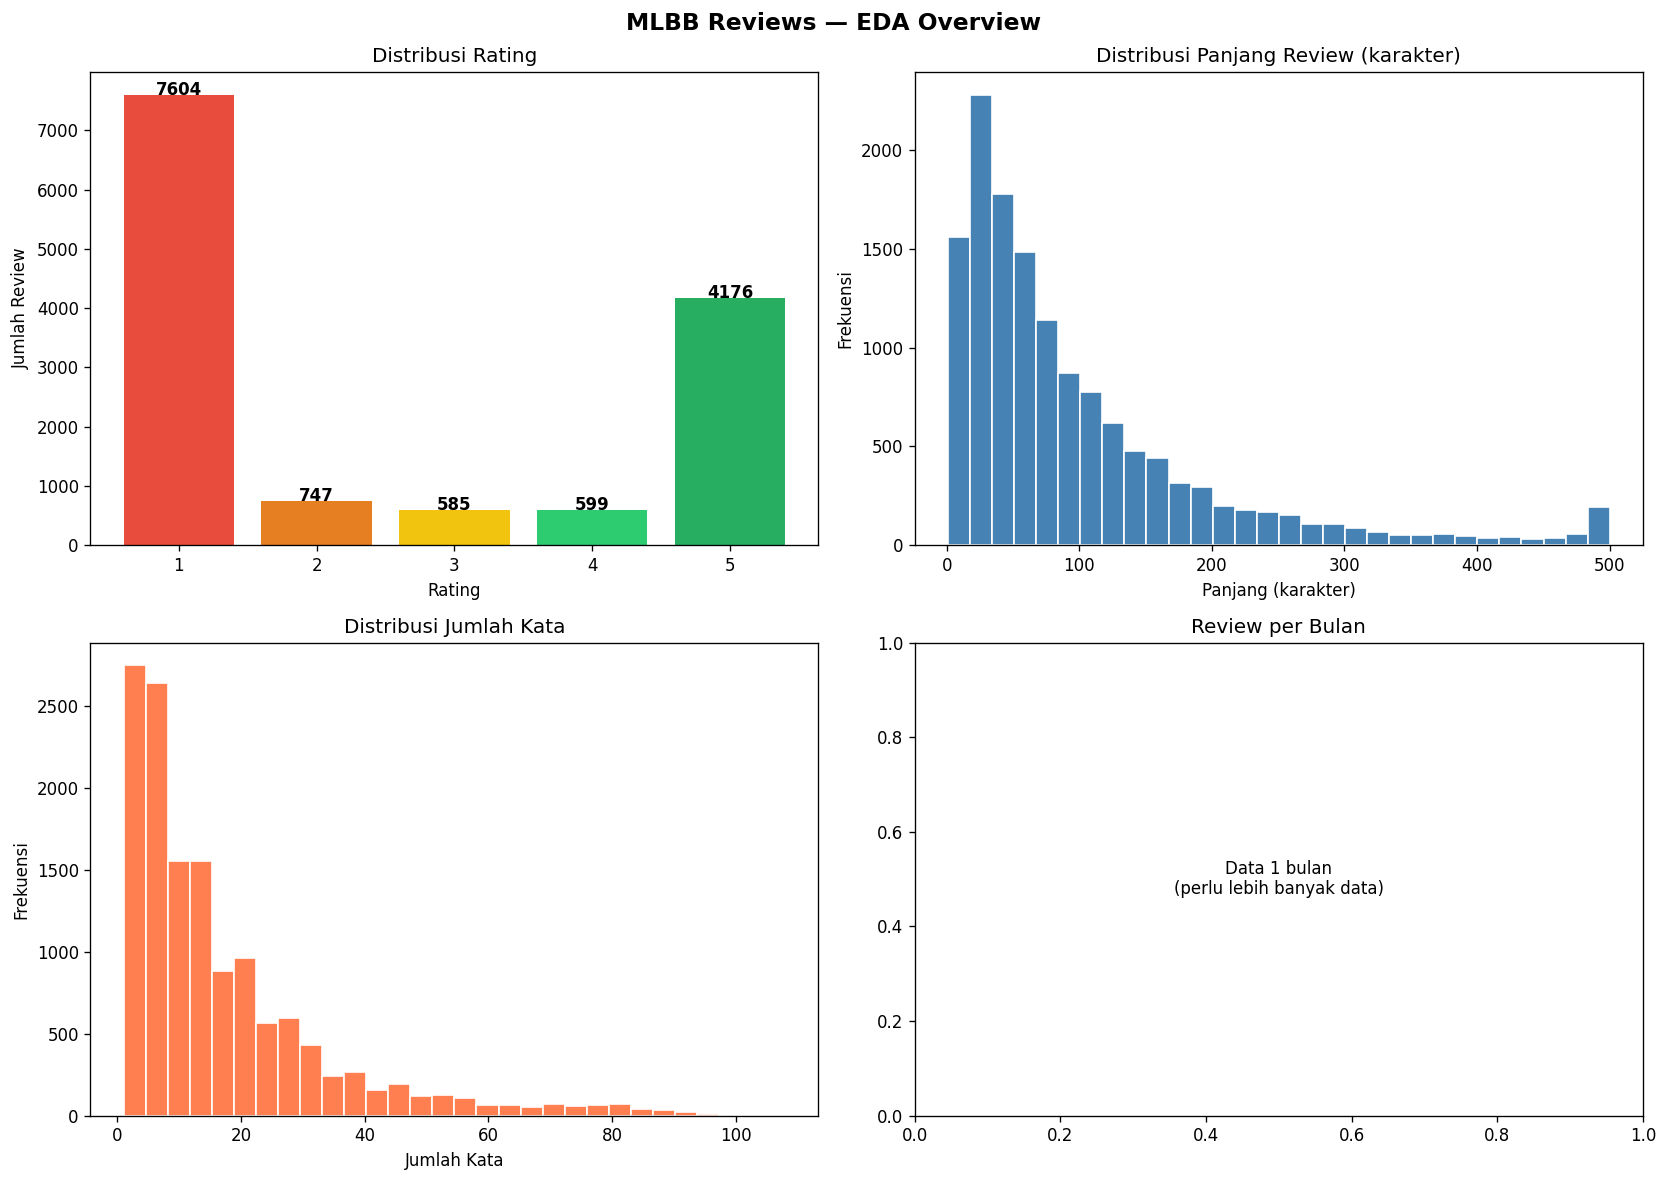


✅ Plot EDA tersimpan: eda_overview.png


In [23]:
# ================================================================
# EDA — Eksplorasi Data Awal
# ================================================================

print('='*60)
print('📊 EKSPLORASI DATA AWAL')
print('='*60)

print('\n[1] Missing Values:')
mv = df.isnull().sum()
print(mv[mv > 0] if mv.sum() > 0 else '   ✅ Tidak ada missing values')

print('\n[2] Distribusi Rating:')
print(df['rating'].value_counts().sort_index())

# Statistik panjang review
df['review_length'] = df['review'].astype(str).apply(len)
df['word_count']    = df['review'].astype(str).apply(lambda x: len(x.split()))
print('\n[3] Statistik Panjang Review:')
print(df[['review_length', 'word_count']].describe().round(2))

# Visualisasi EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MLBB Reviews — EDA Overview', fontsize=14, fontweight='bold')

# Rating distribution
rating_counts = df['rating'].value_counts().sort_index()
colors_rating = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
axes[0,0].bar(rating_counts.index, rating_counts.values, color=colors_rating)
axes[0,0].set_title('Distribusi Rating')
axes[0,0].set_xlabel('Rating'); axes[0,0].set_ylabel('Jumlah Review')
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0,0].text(x, y + 0.1, str(y), ha='center', fontweight='bold')

# Review length
axes[0,1].hist(df['review_length'], bins=30, color='steelblue', edgecolor='white')
axes[0,1].set_title('Distribusi Panjang Review (karakter)')
axes[0,1].set_xlabel('Panjang (karakter)'); axes[0,1].set_ylabel('Frekuensi')

# Word count
axes[1,0].hist(df['word_count'], bins=30, color='coral', edgecolor='white')
axes[1,0].set_title('Distribusi Jumlah Kata')
axes[1,0].set_xlabel('Jumlah Kata'); axes[1,0].set_ylabel('Frekuensi')

# Review per bulan (jika ada kolom tanggal)
if 'tanggal' in df.columns and df['tanggal'].notna().sum() > 0:
    df['bulan'] = df['tanggal'].dt.to_period('M')
    monthly = df.groupby('bulan').size()
    if len(monthly) > 1:
        monthly.plot(ax=axes[1,1], kind='bar', color='mediumseagreen')
        axes[1,1].set_title('Jumlah Review per Bulan')
        axes[1,1].set_xlabel('Bulan'); axes[1,1].set_ylabel('Jumlah Review')
        axes[1,1].tick_params(axis='x', rotation=45)
    else:
        axes[1,1].text(0.5, 0.5, 'Data 1 bulan\n(perlu lebih banyak data)', ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Review per Bulan')
else:
    axes[1,1].text(0.5, 0.5, 'Kolom tanggal\ntidak tersedia', ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Review per Bulan')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()
print('\n✅ Plot EDA tersimpan: eda_overview.png')


## 📚 Cell 4 — Kamus Slang Final (250+ Entri) & Emoji Map

In [24]:
# ================================================================
# KAMUS SLANG FINAL — 250+ Entri, MLBB-Specific
# (Gabungan dari mlbb_preprocessing_optimized.py + mlbb_notebook.ipynb)
# ================================================================

SLANG_DICT_FINAL = {
    # === Typo nama game/perusahaan ===
    'monton':'moonton','muntun':'moonton','munton':'moonton','montoon':'moonton',
    'montun':'moonton','montonn':'moonton','mnton':'moonton',
    'ml':'mobile legends','mlbb':'mobile legends','mobilelegend':'mobile legends',
    'geme':'game','gama':'game','gem':'game','gaem':'game',

    # === Ganti Kata Kasar → Hapus (empty) ===
    'anj':'','anjir':'','anjing':'','tai':'','bangsat':'','kampret':'',
    'bajingan':'','brengsek':'','sialan':'','keparat':'','bedebah':'',
    'laknat':'','celaka':'','setan':'','iblis':'',
    'goblok':'bodoh','goblog':'bodoh','gblok':'bodoh','tolol':'bodoh',
    'bego':'bodoh','bodoamat':'tidak peduli','asu':'','babi':'',
    'monyet':'','idiot':'bodoh','dungu':'bodoh',

    # === Pronoun ===
    'gw':'saya','gua':'saya','gue':'saya','w':'saya','akuu':'saya',
    'lu':'kamu','lo':'kamu','km':'kamu','ente':'kamu','elu':'kamu',

    # === Negasi (PENTING — jangan dihapus) ===
    'gak':'tidak','ngak':'tidak','nggak':'tidak','gk':'tidak','ga':'tidak',
    'enggak':'tidak','nope':'tidak','ngg':'tidak','kagak':'tidak',
    'gada':'tidak ada','gaada':'tidak ada',

    # === Intensifier ===
    'bgt':'banget','bngt':'banget','bget':'banget','bgtt':'banget',
    'bnget':'banget','bener':'benar','bnr':'benar',
    'emg':'memang','emang':'memang','mmg':'memang','emng':'memang',
    'parah':'parah','paraaah':'parah',

    # === Partikel & Konjungsi ===
    'yg':'yang','yng':'yang','dgn':'dengan','dg':'dengan','dgan':'dengan',
    'aja':'saja','aj':'saja','ajh':'saja','jg':'juga','jga':'juga',
    'klo':'kalau','kalo':'kalau','kl':'kalau','klw':'kalau','kalu':'kalau',
    'tp':'tapi','tpi':'tapi','krn':'karena','karna':'karena','krna':'karena',
    'sm':'sama','ama':'sama','sbg':'sebagai','spy':'supaya','biar':'supaya',
    'ttg':'tentang','tntg':'tentang','utk':'untuk','tuk':'untuk','bwt':'untuk',
    'dr':'dari','dri':'dari','pd':'pada','pda':'pada',
    'trs':'terus','trus':'terus',

    # === Waktu/Aspek ===
    'udh':'sudah','udah':'sudah','dah':'sudah','sdh':'sudah','ud':'sudah',
    'blm':'belum','blum':'belum','blom':'belum','msh':'masih','msih':'masih',
    'masi':'masih','skrg':'sekarang','skrang':'sekarang','skrng':'sekarang',
    'ntar':'nanti','tar':'nanti','ntr':'nanti','sdg':'sedang','lg':'sedang',
    'lgi':'sedang',

    # === Kemampuan/Modal ===
    'bs':'bisa','bsa':'bisa','dpt':'dapat','dapet':'dapat','dpet':'dapat',
    'hrs':'harus','hrus':'harus','lbh':'lebih','lebh':'lebih','lbih':'lebih',
    'mo':'mau',

    # === Action Words ===
    'maen':'main','maein':'main','men':'main','maenin':'mainkan',
    'jd':'jadi','jdi':'jadi','dtg':'datang','dtng':'datang',
    'mulu':'melulu','mlulu':'melulu','mlu':'melulu',
    'anikin':'menaikkan','naikin':'menaikkan','turunin':'menurunkan',
    'nurunin':'menurunkan','kasih':'beri','dikasih':'diberi','ngasih':'memberi',
    'bilang':'bicara','ngomong':'bicara','benerin':'perbaiki','fixs':'perbaiki',

    # === Kosakata umum slang ===
    'nih':'ini','neh':'ini','ne':'ini','tuh':'itu','tuu':'itu',
    'dong':'dong','dunk':'dong','donk':'dong','kek':'seperti',
    'kyk':'seperti','kyak':'seperti','mah':'memang',
    'wkwk':'haha','wkwkwk':'haha','wkwkwkwk':'haha',
    'hahaha':'haha','huhu':'sedih','hehehe':'hehe','xixi':'haha',
    'cape':'capek','capee':'capek',
    'kesel':'kesal','keeseel':'kesal','sebal':'kesal',
    'nyebelin':'menyebalkan','sebel':'kesal',
    'susah':'sulit','pusing':'pusing','ribet':'rumit',
    'enak':'menyenangkan','asik':'menyenangkan','seru':'menyenangkan','mantap':'bagus',
    'mantul':'bagus','keren':'bagus','mantabs':'bagus','kerennn':'bagus',
    'bgs':'bagus','jelek':'buruk','buruk':'buruk',
    'sampah':'buruk','smph':'buruk','ancur':'hancur',
    'menyedihkan':'sedih','kecewaa':'kecewa',
    'gk bisa':'tidak bisa','ngga bisa':'tidak bisa',
    'knp':'kenapa','ngaco':'kacau',
    'lostrek':'kalah beruntun','ngestak':'terjebak','stuck':'terjebak',
    'pleas':'tolong','plis':'tolong','pls':'tolong','plz':'tolong',
    'collab':'kolaborasi','setres':'stres','stress':'stres',
    'ngelek':'lag','ngelekin':'lag','gara2':'gara-gara',
    'min':'developer','maer':'mahal','kreeeen':'keren','kereeeen':'keren',
    'bintag':'bintang','jelass':'jelas','bosq':'bos','kang':'kakak',
    'drak sistem':'sistem buruk','dark sistem':'sistem buruk',
    'sistem drak':'sistem buruk','deraksistem':'sistem buruk',
    'fomo':'takut ketinggalan','btw':'ngomong-ngomong','imo':'menurut saya',
    'orng':'orang','org':'orang','tmen':'teman','tmn':'teman','tmann':'teman',

    # === MLBB-Spesifik ===
    'feeder':'pemain buruk','feeders':'pemain buruk','feed':'pemain buruk','feeding':'bermain buruk',
    'noob':'pemain buruk','n00b':'pemain buruk','nub':'pemain buruk','nob':'pemain buruk','noobie':'pemain buruk',
    'afk':'tidak bermain','afkers':'tidak bermain','afker':'tidak bermain',
    'bot':'bot','bots':'bot','script':'bot',
    'matchmaking':'matchmaking','mm':'matchmaking','maching':'matchmaking','matchmake':'matchmaking',
    'rank':'peringkat','ranked':'peringkat','rangking':'peringkat','ranking':'peringkat',
    'nerf':'diperlemah','buff':'diperkuat','buffed':'diperkuat','nerfed':'diperlemah',
    'op':'terlalu kuat','overpowered':'terlalu kuat','imba':'terlalu kuat','overpower':'terlalu kuat',
    'p2w':'bayar untuk menang','pay to win':'bayar untuk menang','pay2win':'bayar untuk menang',
    'skin':'kostum','skins':'kostum',
    'diamond':'berlian','dimo':'berlian','dias':'berlian',
    'hero':'karakter','heroes':'karakter',
    'push':'naik rank','pushing':'naik rank','pusher':'pemain yang push',
    'lose streak':'kalah beruntun','losestreak':'kalah beruntun',
    'win streak':'menang beruntun','winstreak':'menang beruntun',
    'win rate':'tingkat kemenangan','winrate':'tingkat kemenangan','wr':'tingkat kemenangan',
    'lag':'lag','lagg':'lag','lags':'lag','ngelag':'lag','laggy':'lag',
    'bug':'bug','buggy':'bermasalah','bugs':'bug','glitch':'bug','error':'error',
    'update':'pembaruan','updates':'pembaruan','patch':'pembaruan',
    'hack':'curang','hacker':'penipu','cheat':'curang','cheater':'penipu','cheating':'curang',
    'carry':'memimpin tim','carrier':'memimpin','carried':'dibawa menang',
    'gameplay':'permainan','graphic':'grafik','graphics':'grafik',
    'server':'server','koneksi':'koneksi','connection':'koneksi','sinyal':'sinyal','signal':'sinyal',
    'wifi':'wifi','internet':'internet','packet':'paket data','packet loss':'kehilangan paket',
    'damage':'kerusakan','dmg':'kerusakan','cooldown':'waktu tunggu','cd':'waktu tunggu',
    'skill':'kemampuan','skills':'kemampuan','ultimate':'ultimate','ult':'ultimate',
    'tower':'menara','turret':'menara','base':'markas',
    'lord':'lord','turtle':'kura-kura','meta':'meta','season':'musim',
    'balance':'keseimbangan','balancing':'keseimbangan',
    'toxic':'beracun','toxicity':'racun','toxik':'beracun',
    'troll':'troll','trolling':'troll','trollers':'troll',
    'report':'laporkan','ban':'blokir','banned':'diblokir',
    'team':'tim','teams':'tim','teammate':'teman tim','teammates':'teman tim',
    'enemy':'musuh','enemies':'musuh','user':'pengguna',
    'mvp':'pemain terbaik','bronze':'perunggu','silver':'perak','gold':'emas',
    'epic':'epic','legend':'legend','mythic':'mythic','glory':'kemuliaan',
    'star':'bintang','stars':'bintang','point':'poin','points':'poin',
    'offlaner':'penyerang tepi','jungler':'pemburu hutan','jungle':'hutan',
    'laner':'pemain jalur','mid':'tengah','exp lane':'jalur exp','gold lane':'jalur emas',
    'roam':'roam','roamer':'roamer','support':'pendukung','tank':'tank',
    'mage':'penyihir','marksman':'penembak','assassin':'pembunuh','fighter':'pejuang',
    'event':'event','events':'event','mission':'misi','missions':'misi',
    'chest':'kotak','spin':'putar','gacha':'gacha',
    'tournament':'turnamen','esport':'esport','pro':'profesional',
    'surrender':'menyerah','surr':'menyerah','ff':'menyerah',
    'recall':'mundur','heal':'sembuhkan','shield':'perisai',
    'kritik':'kritik','ping':'ping','fps':'fps',

    # === Code-mixing Inggris → Indonesia ===
    'good':'bagus','great':'bagus','nice':'bagus','best':'terbaik','well':'bagus',
    'bad':'buruk','worst':'terburuk','terrible':'sangat buruk','awful':'sangat buruk',
    'fix':'perbaiki','fixing':'memperbaiki','fixed':'diperbaiki',
    'thanks':'terima kasih','thx':'terima kasih','makasih':'terima kasih','makasi':'terima kasih',
    'sorry':'maaf','sori':'maaf',
    'love':'suka','like':'suka','enjoy':'menikmati','fun':'menyenangkan',
    'hate':'benci','dislike':'tidak suka',
    'slow':'lambat','fast':'cepat','heavy':'berat','smooth':'lancar',
    'free':'gratis','paid':'berbayar','cheap':'murah','expensive':'mahal',
    'hard':'sulit','easy':'mudah','fair':'adil','unfair':'tidak adil',
    'problem':'masalah','issue':'masalah','crash':'crash','down':'mati',
    'loading':'loading','login':'masuk','logout':'keluar',
    'account':'akun','acc':'akun',
    'reward':'hadiah','gift':'hadiah','prize':'hadiah',
    'mode':'mode','custom':'kustom','map':'peta','mini map':'peta mini',
    'omg':'','fyp':'trending','lol':'haha','lmao':'haha',
    'yes':'ya','no':'tidak','ok':'oke','okay':'oke',
    'wow':'wah','wah':'wah','aduh':'aduh','duh':'aduh',

    # === Typo spesifik ===
    'pdahal':'padahal','sebenrnya':'sebenarnya','sbnrnya':'sebenarnya',
    'bnyak':'banyak','bnyk':'banyak','banyakk':'banyak',
    'smua':'semua','smuanya':'semuanya',
    'slalu':'selalu','sllau':'selalu',
    'kdg':'kadang','kdng':'kadang',
    'pake':'pakai','pakek':'pakai','pkai':'pakai',
    'lmbt':'lambat','lemot':'lambat','cpat':'cepat','cpt':'cepat',
    'mntaa':'minta','hrp':'harap','tlng':'tolong','tlg':'tolong',
    'mohonn':'mohon','smoga':'semoga','syg':'sayang','sk':'suka',
    'cintta':'suka','lmaa':'lama',
    'match':'pertandingan','matchnya':'pertandingannya',
    'playernya':'pemainnya','timnya':'timnya','teamnya':'timnya',
    'akunnya':'akunnya','akunya':'akunnya','gamesnya':'gamenya',
}

# ================================================================
# EMOJI → TEKS (Konteks Emosional MLBB)
# ================================================================

EMOJI_TO_TEXT = {
    '😭':' sangat sedih ','😢':' sedih ','😞':' kecewa ','😔':' kecewa ',
    '😡':' marah ','🤬':' sangat marah ','😤':' kesal ','😠':' marah ',
    '😒':' kecewa ','😩':' frustasi ','🙁':' tidak senang ',
    '😐':' biasa ','😑':' ekspresi datar ',
    '😊':' senang ','😄':' gembira ','😍':' sangat suka ','🥰':' suka ',
    '😎':' keren ','🤩':' kagum ','😂':' lucu ','🤣':' lucu ',
    '👍':' bagus ','👎':' buruk ','✅':' setuju ','❌':' tidak setuju ',
    '🔥':' keren ','💔':' kecewa ','❤️':' suka ','💪':' kuat ',
    '🙏':' mohon ','⭐':' bintang ','🌟':' bintang ',
    '💎':' berlian ','🏆':' juara ','🚀':' cepat ','💸':' mahal ',
    '🎮':' game ',
}

print(f'✅ Kamus slang dimuat: {len(SLANG_DICT_FINAL)} entri')
print(f'✅ Emoji map dimuat  : {len(EMOJI_TO_TEXT)} entri')


✅ Kamus slang dimuat: 509 entri
✅ Emoji map dimuat  : 37 entri


## 🔧 Cell 5 — Preprocessing Functions (Layered & Gentle)

In [25]:
# ================================================================
# SETUP STEMMER & STOPWORDS
# ================================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

sw_factory = StopWordRemoverFactory()
sastrawi_sw = set(sw_factory.get_stop_words())
nltk_sw = set(nltk.corpus.stopwords.words('indonesian'))

MLBB_STOPWORDS = {'mobile', 'legends', 'game', 'aplikasi', 'play', 'store',
                  'developer', 'moonton', 'mlbb', 'ml'}

# Kata yang TIDAK boleh di-stem (penting untuk sentimen)
SENTIMENT_PROTECT = {
    'tidak','bukan','jangan','belum','sudah','pernah','selalu',
    'sering','jarang','kadang','hampir','sangat','sekali','banget',
    'terlalu','lebih','kurang','cukup','lumayan','agak',
    'bagus','baik','buruk','jelek','keren','mantap','seru','enak',
    'susah','sulit','mudah','gampang','senang','sedih','marah',
    'kesal','kecewa','puas','bosan','capek','lelah',
    'suka','cinta','benci','takut','rindu',
    'parah','ancur','sampah','lambat','cepat','lancar','lag','bug','error',
    'adil','curang','jujur','benar','salah',
    'gratis','mahal','murah','bayar','rugi','untung',
    'perbaiki','rusak','hancur','hilang',
    'tolong','mohon','harap','semoga','minta',
    'kecewa','bangga','menyesal','takjub','heran',
    'beracun','kalah','menang',
}

# Stopwords yang TETAP dipertahankan
KEEP_WORDS = {
    'tidak','bukan','jangan','belum','pernah','hampir',
    'sangat','terlalu','paling','sekali','banget',
    'bagus','baik','buruk','jelek','seru','enak',
    'susah','mudah','senang','sedih','marah','kesal','kecewa','puas',
    'suka','benci','rugi','kalah','menang',
    'lag','lambat','cepat','crash','error','bug','rusak',
    'mahal','murah','gratis',
}

ALL_STOPWORDS = (sastrawi_sw | nltk_sw | MLBB_STOPWORDS) - KEEP_WORDS

# ================================================================
# FUNGSI PREPROCESSING
# ================================================================

def convert_emoji(text: str) -> str:
    """Konversi emoji ke teks deskriptif."""
    for em, label in EMOJI_TO_TEXT.items():
        text = text.replace(em, label)
    text = emoji.replace_emoji(text, replace=' ')
    return text

def case_fold(text: str) -> str:
    return text.lower()

def clean_chars(text: str) -> str:
    """Bersihkan URL, HTML, mention, angka, punctuation."""
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'[!"#$%&\'()*+,\./:;<=>?@\[\\\]^_`{|}~]', ' ', text)
    text = re.sub(r'[^\x00-\x7Fa-zA-Z\s\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_repeating(text: str) -> str:
    """Normalisasi huruf berulang (3+ → 2)."""
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'(\b\w+\b)[\s"\-]+\1', r'\1', text)
    return text

def normalize_slang(text: str) -> str:
    """Normalisasi slang dengan kamus FINAL (bigram + unigram)."""
    words = text.split()
    result = []
    i = 0
    while i < len(words):
        if i + 1 < len(words):
            bigram = words[i] + ' ' + words[i+1]
            if bigram in SLANG_DICT_FINAL:
                replacement = SLANG_DICT_FINAL[bigram]
                if replacement:
                    result.append(replacement)
                i += 2
                continue
        w = words[i]
        if w in SLANG_DICT_FINAL:
            replacement = SLANG_DICT_FINAL[w]
            if replacement:
                result.append(replacement)
        else:
            result.append(w)
        i += 1
    return ' '.join(result)

def tokenize(text: str) -> list:
    return [w for w in text.split() if len(w) > 1]

def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t not in ALL_STOPWORDS]

def stem_tokens(tokens: list) -> list:
    """Gentle stemming — skip kata yang penting untuk sentimen."""
    return [stemmer.stem(t) if t not in SENTIMENT_PROTECT else t for t in tokens]

def preprocess_full(text: str, apply_stopword=False, apply_stem=False) -> str:
    """
    Pipeline preprocessing lengkap.
    - apply_stopword=False → untuk LSTM/IndoBERT
    - apply_stopword=True  → untuk Topic Modeling
    - apply_stem=True      → untuk Traditional ML
    """
    if pd.isna(text) or str(text).strip() == '':
        return ''
    text = str(text)
    text = convert_emoji(text)
    text = case_fold(text)
    text = clean_chars(text)
    text = normalize_repeating(text)
    text = normalize_slang(text)
    tokens = tokenize(text)
    if apply_stopword:
        tokens = remove_stopwords(tokens)
    if apply_stem:
        tokens = stem_tokens(tokens)
    return ' '.join(tokens)

# Quick test
test_cases = [
    'milih tim nya aneh ngak sesuai sama lawan malah tambah ngak jelass!!',
    'bagusssss banget gamenya suka bangettt sama hero barunya kereeeen!!!',
    'matchmaking rusak bgt, rank gw turun terus gara2 dapet tim feeder mulu 😡😡',
    'plis lah monton gw cape anikin reng tapi knp di kasih tim bot semua',
    'min kurangi deraksistem nya bikin setres masa miya exp yang bener lah min',
]
print('✅ Fungsi preprocessing berhasil dimuat')
print('\n📝 Quick Test:')
for i, tc in enumerate(test_cases, 1):
    result = preprocess_full(tc, apply_stopword=False, apply_stem=False)
    src = f'{tc[:70]}...' if len(tc) > 70 else tc
    print(f'  [{i}] SEBELUM: {src}')
    print(f'       SESUDAH: {result}\n')


✅ Fungsi preprocessing berhasil dimuat

📝 Quick Test:
  [1] SEBELUM: milih tim nya aneh ngak sesuai sama lawan malah tambah ngak jelass!!
       SESUDAH: milih tim nya aneh tidak sesuai sama lawan malah tambah tidak jelas

  [2] SEBELUM: bagusssss banget gamenya suka bangettt sama hero barunya kereeeen!!!
       SESUDAH: baguss banget gamenya suka bangett sama karakter barunya kereen

  [3] SEBELUM: matchmaking rusak bgt, rank gw turun terus gara2 dapet tim feeder mulu...
       SESUDAH: matchmaking rusak banget peringkat saya turun terus gara-gara dapat tim pemain buruk melulu marah

  [4] SEBELUM: plis lah monton gw cape anikin reng tapi knp di kasih tim bot semua
       SESUDAH: tolong lah moonton saya capek menaikkan reng tapi kenapa di beri tim bot semua

  [5] SEBELUM: min kurangi deraksistem nya bikin setres masa miya exp yang bener lah ...
       SESUDAH: developer kurangi sistem buruk nya bikin stres masa miya exp yang benar lah developer



## ⚙️ Cell 6 — Terapkan Preprocessing ke Dataset

In [26]:
# ================================================================
# TERAPKAN PREPROCESSING — 3 VERSI OUTPUT
# ================================================================

print('⏳ Memproses dataset...')

# Drop baris kosong
df = df.dropna(subset=['review']).reset_index(drop=True)
df = df[df['review'].astype(str).str.strip() != ''].reset_index(drop=True)

# Simpan versi review asli sebelum preprocessing
df['review_raw'] = df['review'].astype(str)

# [1/3] Untuk Sentiment Analysis & LSTM/IndoBERT (tanpa stopword & stem)
print('\n[1/3] review_clean — untuk Sentiment Analysis / LSTM / IndoBERT...')
df['review_clean'] = df['review'].progress_apply(
    lambda x: preprocess_full(x, apply_stopword=False, apply_stem=False)
)

# [2/3] Untuk Traditional ML (tanpa stopword, dengan stemming)
print('\n[2/3] review_stemmed — untuk Traditional ML (NB, SVM, etc.)...')
df['review_stemmed'] = df['review'].progress_apply(
    lambda x: preprocess_full(x, apply_stopword=False, apply_stem=True)
)

# [3/3] Untuk Topic Modeling (stopword + stemming)
print('\n[3/3] review_topic — untuk Topic Modeling (LDA, NMF)...')
df['review_topic'] = df['review'].progress_apply(
    lambda x: preprocess_full(x, apply_stopword=True, apply_stem=True)
)

# Statistik
df['review_clean_length'] = df['review_clean'].apply(len)
df['review_clean_words']  = df['review_clean'].apply(lambda x: len(x.split()))

# Drop review yang jadi kosong setelah preprocessing
n_empty = (df['review_clean'].str.strip() == '').sum()
if n_empty > 0:
    print(f'\n⚠️  {n_empty} review menjadi kosong setelah preprocessing → dihapus')
    df = df[df['review_clean'].str.strip() != ''].reset_index(drop=True)

print(f'\n✅ Preprocessing selesai!')
print(f'   Total baris valid : {len(df):,}')
print(f'\n--- Sample perbandingan (3 baris pertama) ---')
df[['review', 'review_clean', 'review_stemmed']].head(3)


⏳ Memproses dataset...

[1/3] review_clean — untuk Sentiment Analysis / LSTM / IndoBERT...


100%|██████████| 13711/13711 [00:07<00:00, 1738.97it/s]



[2/3] review_stemmed — untuk Traditional ML (NB, SVM, etc.)...


100%|██████████| 13711/13711 [00:14<00:00, 972.17it/s] 



[3/3] review_topic — untuk Topic Modeling (LDA, NMF)...


100%|██████████| 13711/13711 [00:06<00:00, 2054.83it/s]



⚠️  35 review menjadi kosong setelah preprocessing → dihapus

✅ Preprocessing selesai!
   Total baris valid : 13,676

--- Sample perbandingan (3 baris pertama) ---


,review,review_clean,review_stemmed
0,keren banget!!! Saya suka sama gameplay dan juga hero² nya! event² juga tidak ribet dan gampang untuk di mengerti. Dan juga Gift Away nya gk pelit²! ini 💯 banget!,bagus banget saya suka sama permainan dan juga karakter nya event juga tidak rumit dan gampang untuk di mengerti dan juga hadiah away nya tidak pelit ini banget,bagus banget saya suka sama main dan juga karakter nya event juga tidak rumit dan gampang untuk di erti dan juga hadiah away nya tidak pelit ini banget
1,Pemain nya Ramah semua,pemain nya ramah semua,main nya ramah semua
2,sinyalnya jelek pdahal udah penuh loh itu wifinya kesel jadinya ke turret mulu dan matchnya lama terus playernya toxic,sinyalnya buruk padahal sudah penuh loh itu wifinya kesal jadinya ke menara melulu dan pertandingannya lama terus pemainnya beracun,sinyal buruk padahal sudah penuh loh itu wifinya kesal jadi ke menara melulu dan tanding lama terus main beracun


## 🏷️ Cell 7 — Labeling Sentimen dari Rating


📊 Distribusi Sentimen (Ground Truth dari Rating):
   Negatif : 8,343 (61.00%)
   Positif : 4,749 (34.73%)
   Netral  :   584 ( 4.27%)


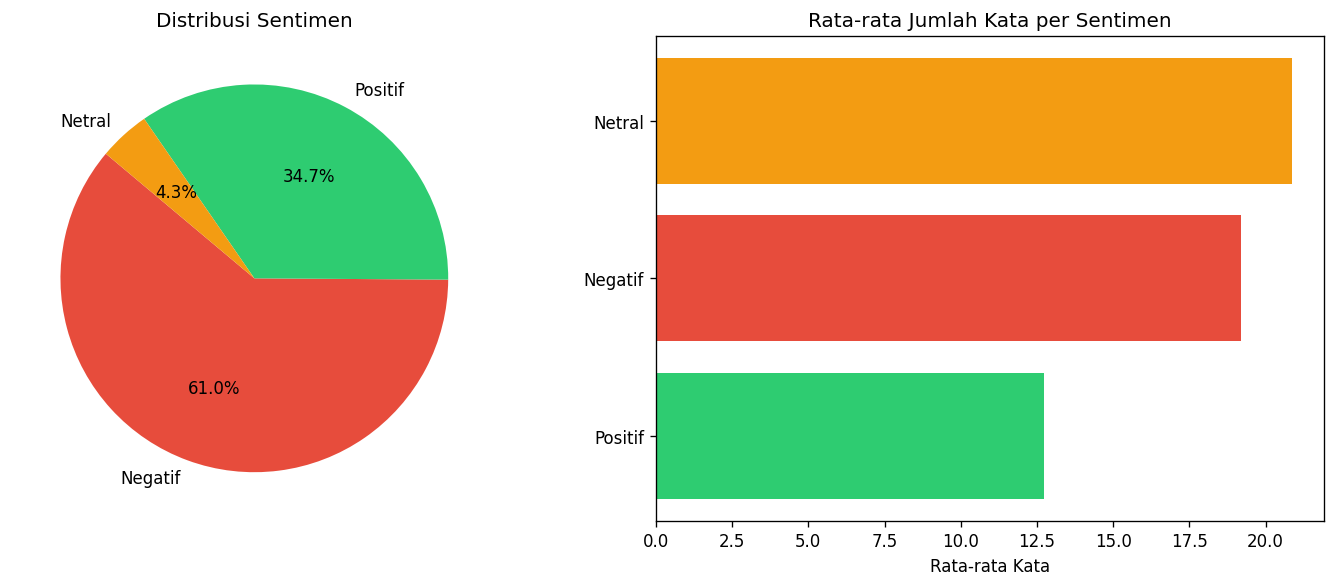


✅ Labeling selesai. Plot tersimpan: sentiment_distribution.png


In [27]:
# ================================================================
# LABELING — Ground Truth dari Rating
# Rating 1-2 → Negatif | Rating 3 → Netral | Rating 4-5 → Positif
# ================================================================

def rating_to_sentiment(rating):
    if pd.isna(rating):
        return 'Unknown'
    r = int(rating)
    if r <= 2:
        return 'Negatif'
    elif r == 3:
        return 'Netral'
    else:
        return 'Positif'

df['sentiment_label'] = df['rating'].apply(rating_to_sentiment)
df['sentiment_id']    = df['sentiment_label'].map({'Negatif': 0, 'Netral': 1, 'Positif': 2, 'Unknown': -1})

LABEL_MAP = {'Negatif': 0, 'Netral': 1, 'Positif': 2}

sentiment_dist = df['sentiment_label'].value_counts()
print('\n📊 Distribusi Sentimen (Ground Truth dari Rating):')
for label, count in sentiment_dist.items():
    pct = count / len(df) * 100
    print(f'   {label:8s}: {count:5,} ({pct:5.2f}%)')

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_map = {'Positif': '#2ecc71', 'Netral': '#f39c12', 'Negatif': '#e74c3c', 'Unknown': '#95a5a6'}

colors_pie = [colors_map.get(c, 'grey') for c in sentiment_dist.index]
axes[0].pie(sentiment_dist.values, labels=sentiment_dist.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=140)
axes[0].set_title('Distribusi Sentimen')

avg_len = df.groupby('sentiment_label')['review_clean_words'].mean().sort_values()
bar_colors = [colors_map.get(c, 'grey') for c in avg_len.index]
axes[1].barh(avg_len.index, avg_len.values, color=bar_colors)
axes[1].set_title('Rata-rata Jumlah Kata per Sentimen')
axes[1].set_xlabel('Rata-rata Kata')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', bbox_inches='tight')
plt.show()
print('\n✅ Labeling selesai. Plot tersimpan: sentiment_distribution.png')


## 💬 Cell 8 — VADER Baseline Sentiment Scoring

In [28]:
# ================================================================
# VADER BASELINE — Lexicon-Based Sentiment
# Catatan: VADER dioptimasi untuk Inggris; digunakan sebagai baseline
# ================================================================

vader = SentimentIntensityAnalyzer()

def vader_sentiment(text: str) -> dict:
    scores = vader.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positif'
    elif compound <= -0.05:
        label = 'Negatif'
    else:
        label = 'Netral'
    return {
        'vader_pos'      : round(scores['pos'], 4),
        'vader_neg'      : round(scores['neg'], 4),
        'vader_neu'      : round(scores['neu'], 4),
        'vader_compound' : round(compound, 4),
        'vader_label'    : label,
    }

print('⏳ Menjalankan VADER scoring...')
vader_results = df['review_clean'].progress_apply(vader_sentiment)
vader_df      = pd.DataFrame(vader_results.tolist())
df            = pd.concat([df.reset_index(drop=True), vader_df], axis=1)

# Akurasi VADER
valid_vader = df[df['sentiment_label'].isin(['Positif', 'Netral', 'Negatif'])]
match = (valid_vader['vader_label'] == valid_vader['sentiment_label']).sum()
print(f'\n✅ VADER selesai.')
print(f'   Akurasi VADER vs Ground Truth: {match}/{len(valid_vader)} = {match/len(valid_vader)*100:.1f}%')
print('   (VADER adalah baseline; IndoBERT akan lebih akurat untuk Bahasa Indonesia)')
print('\n📊 VADER Classification Report:')
print(classification_report(valid_vader['sentiment_label'], valid_vader['vader_label'],
                            labels=['Positif', 'Netral', 'Negatif'], zero_division=0))
df[['review', 'review_clean', 'sentiment_label', 'vader_label', 'vader_compound']].head(5)


⏳ Menjalankan VADER scoring...


100%|██████████| 13676/13676 [00:01<00:00, 11585.63it/s]



✅ VADER selesai.
   Akurasi VADER vs Ground Truth: 1649/13676 = 12.1%
   (VADER adalah baseline; IndoBERT akan lebih akurat untuk Bahasa Indonesia)

📊 VADER Classification Report:
              precision    recall  f1-score   support

     Positif       0.27      0.07      0.11      4749
      Netral       0.04      0.77      0.08       584
     Negatif       0.70      0.11      0.18      8343

    accuracy                           0.12     13676
   macro avg       0.34      0.31      0.12     13676
weighted avg       0.52      0.12      0.15     13676



,review,review_clean,sentiment_label,vader_label,vader_compound
0,keren banget!!! Saya suka sama gameplay dan juga hero² nya! event² juga tidak ribet dan gampang untuk di mengerti. Dan juga Gift Away nya gk pelit²! ini 💯 banget!,bagus banget saya suka sama permainan dan juga karakter nya event juga tidak rumit dan gampang untuk di mengerti dan juga hadiah away nya tidak pelit ini banget,Positif,Netral,0.0
1,Pemain nya Ramah semua,pemain nya ramah semua,Negatif,Netral,0.0
2,sinyalnya jelek pdahal udah penuh loh itu wifinya kesel jadinya ke turret mulu dan matchnya lama terus playernya toxic,sinyalnya buruk padahal sudah penuh loh itu wifinya kesal jadinya ke menara melulu dan pertandingannya lama terus pemainnya beracun,Negatif,Netral,0.0
3,geme ga niat terlalu banyak di kasih kalah,game tidak niat terlalu banyak di beri kalah,Negatif,Netral,0.0
4,"kalo mau main custom pasti musuhnya jago,terus kalo saya mati/KO pasti temannya malah muter muter ga jelas",kalau mau main kustom pasti musuhnya jago terus kalau saya mati ko pasti temannya malah muter tidak jelas,Negatif,Netral,0.0


## 🤖 Cell 9 — IndoBERT Sentiment Analysis

In [29]:
# ================================================================
# INDOBERT INFERENCE
# Model: mdhugol/indonesia-bert-sentiment-classification
# Label: LABEL_0=Positif, LABEL_1=Netral, LABEL_2=Negatif
# ================================================================

INDOBERT_MODEL    = 'mdhugol/indonesia-bert-sentiment-classification'
INDOBERT_LABEL_MAP = {'LABEL_0': 'Positif', 'LABEL_1': 'Netral', 'LABEL_2': 'Negatif'}

print('⏳ Memuat model IndoBERT...')
print(f'   Model : {INDOBERT_MODEL}')
print(f'   Device: {"GPU" if torch.cuda.is_available() else "CPU"}')

try:
    device = 0 if torch.cuda.is_available() else -1
    indobert_pipe = hf_pipeline(
        'text-classification',
        model=INDOBERT_MODEL,
        tokenizer=INDOBERT_MODEL,
        device=device,
        truncation=True,
        max_length=512,
    )

    def indobert_predict(text: str) -> dict:
        if not text or str(text).strip() == '':
            return {'indobert_label': 'Netral', 'indobert_score': 0.0}
        try:
            result = indobert_pipe(str(text)[:512])[0]
            return {
                'indobert_label': INDOBERT_LABEL_MAP.get(result['label'], result['label']),
                'indobert_score': round(result['score'], 4),
            }
        except Exception:
            return {'indobert_label': 'Error', 'indobert_score': 0.0}

    print('\n⏳ Menjalankan IndoBERT inference (ini membutuhkan beberapa menit)...')
    indobert_results = df['review_clean'].progress_apply(indobert_predict)
    indobert_df      = pd.DataFrame(indobert_results.tolist())
    df               = pd.concat([df.reset_index(drop=True), indobert_df], axis=1)

    valid2 = df[df['sentiment_label'].isin(['Positif', 'Netral', 'Negatif'])]
    match2 = (valid2['indobert_label'] == valid2['sentiment_label']).sum()
    print(f'\n✅ IndoBERT selesai!')
    print(f'   Akurasi IndoBERT vs Ground Truth: {match2}/{len(valid2)} = {match2/len(valid2)*100:.1f}%')
    print('\n📊 IndoBERT Classification Report:')
    print(classification_report(valid2['sentiment_label'], valid2['indobert_label'],
                                labels=['Positif', 'Netral', 'Negatif'], zero_division=0))

except Exception as e:
    print(f'\n⚠️  IndoBERT tidak dapat dimuat: {e}')
    print('   → Pastikan koneksi internet tersedia untuk download model.')
    print('   → Melanjutkan tanpa IndoBERT.')
    df['indobert_label'] = df['vader_label']  # fallback ke VADER
    df['indobert_score'] = 0.0

df[['review', 'review_clean', 'sentiment_label', 'vader_label', 'indobert_label']].head(5)


⏳ Memuat model IndoBERT...
   Model : mdhugol/indonesia-bert-sentiment-classification
   Device: GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



⏳ Menjalankan IndoBERT inference (ini membutuhkan beberapa menit)...


100%|██████████| 13676/13676 [02:50<00:00, 80.06it/s] 



✅ IndoBERT selesai!
   Akurasi IndoBERT vs Ground Truth: 10394/13676 = 76.0%

📊 IndoBERT Classification Report:
              precision    recall  f1-score   support

     Positif       0.82      0.62      0.70      4749
      Netral       0.05      0.06      0.05       584
     Negatif       0.79      0.89      0.84      8343

    accuracy                           0.76     13676
   macro avg       0.55      0.52      0.53     13676
weighted avg       0.77      0.76      0.76     13676



,review,review_clean,sentiment_label,vader_label,indobert_label
0,keren banget!!! Saya suka sama gameplay dan juga hero² nya! event² juga tidak ribet dan gampang untuk di mengerti. Dan juga Gift Away nya gk pelit²! ini 💯 banget!,bagus banget saya suka sama permainan dan juga karakter nya event juga tidak rumit dan gampang untuk di mengerti dan juga hadiah away nya tidak pelit ini banget,Positif,Netral,Positif
1,Pemain nya Ramah semua,pemain nya ramah semua,Negatif,Netral,Positif
2,sinyalnya jelek pdahal udah penuh loh itu wifinya kesel jadinya ke turret mulu dan matchnya lama terus playernya toxic,sinyalnya buruk padahal sudah penuh loh itu wifinya kesal jadinya ke menara melulu dan pertandingannya lama terus pemainnya beracun,Negatif,Netral,Negatif
3,geme ga niat terlalu banyak di kasih kalah,game tidak niat terlalu banyak di beri kalah,Negatif,Netral,Negatif
4,"kalo mau main custom pasti musuhnya jago,terus kalo saya mati/KO pasti temannya malah muter muter ga jelas",kalau mau main kustom pasti musuhnya jago terus kalau saya mati ko pasti temannya malah muter tidak jelas,Negatif,Netral,Negatif


## 🔄 Cell 10 — Label Correction (Keyword + Pattern + IndoBERT)

⏳ Menjalankan label correction...


100%|██████████| 13676/13676 [00:00<00:00, 19453.53it/s]



✅ Label correction selesai!
   Label dikoreksi : 3,482 (25.5%)
   Konsistensi sebelum: 76.0%
   Konsistensi setelah: 90.6%


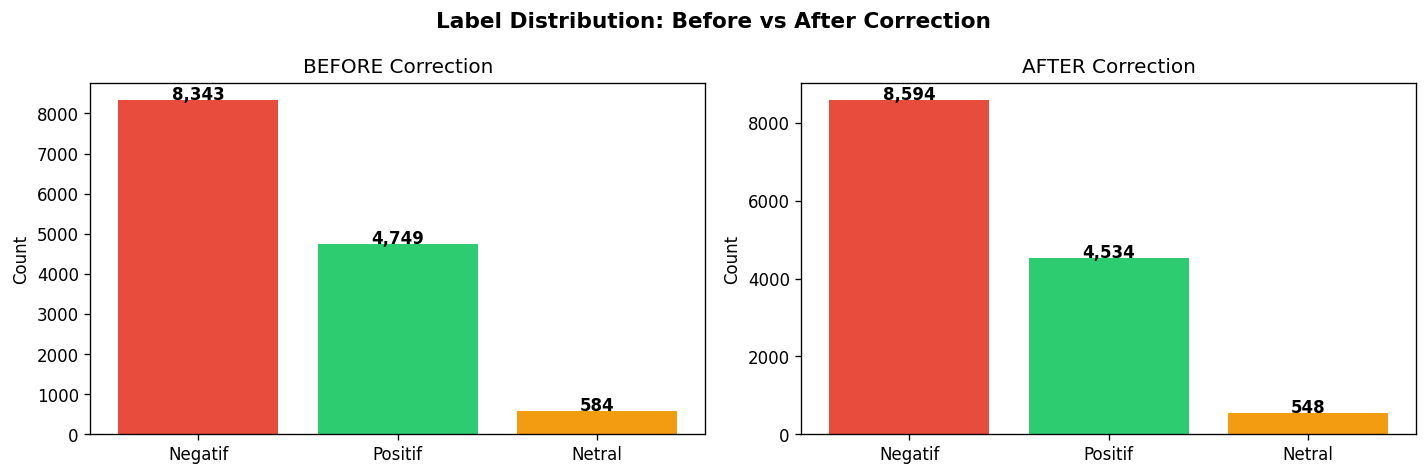


✅ Plot label distribution tersimpan: label_distribution.png


In [30]:
# ================================================================
# LABEL CORRECTION — Koreksi label menggunakan
# keyword counting + regex pattern + IndoBERT fallback
# ================================================================

POSITIVE_KEYWORDS = [
    'bagus','baik','keren','mantap','seru','enak','lancar','smooth','suka',
    'senang','puas','bagusnya','mantul','luar biasa','recommended',
    'menyenangkan','asik','asyik','top','sempurna','baguss','kerennn',
    'love','gembira','menikmati','terbaik','favorit',
]

NEGATIVE_KEYWORDS = [
    'buruk','jelek','parah','rusak','lambat','lag','bug','error','kecewa',
    'kesal','marah','sedih','frustasi','tidak bisa','tidak jalan','hancur',
    'sampah','payah','mengecewakan','benci','susah','sulit','ribet',
    'toxic','curang','tidak adil','lose streak','lose','kalah','ancur',
    'tidak menyenangkan','menyebalkan','tidak suka','omg','cape',
]

def count_keywords(text: str, keyword_list: list) -> int:
    if not text:
        return 0
    return sum(1 for kw in keyword_list if kw in text.lower())

STRONG_POS_PATTERNS = [
    r'\b(sangat|amat|benar-benar|sungguh)\s+(bagus|keren|mantap|seru|suka)\b',
    r'\b(bagus|keren|mantap|suka)\s+(banget|sekali)\b',
    r'\b(game|aplikasi)\s+(terbaik|sangat bagus)\b',
]
STRONG_NEG_PATTERNS = [
    r'\b(sangat|amat|benar-benar|sungguh)\s+(buruk|jelek|parah|kecewa)\b',
    r'\b(buruk|jelek|parah)\s+(banget|sekali)\b',
    r'\b(tidak|gak|ga)\s+(bisa|jalan|fungsi)\b',
    r'\blag\s+terus\b', r'\bbug\s+mulu\b', r'\brusak\s+parah\b',
]

def final_label_correction(row) -> str:
    """Koreksi label: keyword counting + regex + IndoBERT fallback."""
    text   = str(row.get('review_clean', ''))
    orig   = row.get('sentiment_label', 'Netral')
    bert   = row.get('indobert_label', 'Netral')

    pos_score = count_keywords(text, POSITIVE_KEYWORDS)
    neg_score = count_keywords(text, NEGATIVE_KEYWORDS)

    # Pattern override
    strong_pos = any(re.search(p, text) for p in STRONG_POS_PATTERNS)
    strong_neg = any(re.search(p, text) for p in STRONG_NEG_PATTERNS)

    if strong_pos and not strong_neg:
        return 'Positif'
    if strong_neg and not strong_pos:
        return 'Negatif'

    # Keyword voting
    if pos_score > 0 and neg_score == 0:
        return 'Positif'
    if neg_score > 0 and pos_score == 0:
        return 'Negatif'

    # Majority vote: original + IndoBERT
    votes = [orig, bert]
    pos_v = votes.count('Positif')
    neg_v = votes.count('Negatif')
    if pos_v >= 2:
        return 'Positif'
    if neg_v >= 2:
        return 'Negatif'

    # Fallback ke IndoBERT jika keycount seimbang
    if bert in ['Positif', 'Netral', 'Negatif']:
        return bert
    # Jika pos_score == neg_score dan bukan 0: kembalikan orig (bisa Netral)
    if pos_score == neg_score:
        return orig
    return orig

print('⏳ Menjalankan label correction...')
df['label_corrected'] = df.progress_apply(final_label_correction, axis=1)
df['label_id'] = df['label_corrected'].map({'Negatif': 0, 'Netral': 1, 'Positif': 2})

changed = (df['label_corrected'] != df['sentiment_label']).sum()
print(f'\n✅ Label correction selesai!')
print(f'   Label dikoreksi : {changed:,} ({changed/len(df)*100:.1f}%)')

# Konsistensi sebelum & sesudah
consistency_before = (df['sentiment_label'] == df['indobert_label']).mean() * 100
consistency_after  = (df['label_corrected'] == df['indobert_label']).mean() * 100
print(f'   Konsistensi sebelum: {consistency_before:.1f}%')
print(f'   Konsistensi setelah: {consistency_after:.1f}%')

# Visualisasi distribusi sebelum & sesudah koreksi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Label Distribution: Before vs After Correction', fontsize=13, fontweight='bold')
colors = {'Negatif': '#e74c3c', 'Netral': '#f39c12', 'Positif': '#2ecc71'}

before = df['sentiment_label'].value_counts()
after  = df['label_corrected'].value_counts()

axes[0].bar(before.index, before.values, color=[colors.get(l, 'gray') for l in before.index])
axes[0].set_title('BEFORE Correction')
axes[0].set_ylabel('Count')
for i, (l, v) in enumerate(zip(before.index, before.values)):
    axes[0].text(i, v + 0.5, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(after.index, after.values, color=[colors.get(l, 'gray') for l in after.index])
axes[1].set_title('AFTER Correction')
axes[1].set_ylabel('Count')
for i, (l, v) in enumerate(zip(after.index, after.values)):
    axes[1].text(i, v + 0.5, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n✅ Plot label distribution tersimpan: label_distribution.png')


## 📊 Cell 11 — Optimization Analysis & Vocabulary Report

📚 Vocabulary Size:
   review_clean   : 12,360 kata unik
   review_stemmed : 10,187 kata unik  (-2,173 by stemming)
   review_topic   : 10,045 kata unik  (-142 by stopword)

📏 Avg words:
   review_clean   : 17.0
   review_stemmed : 17.0

🔤 Top 15 Kata — review_clean:
    1. game                     : 7,994
    2. tidak                    : 6,625
    3. saya                     : 5,989
    4. yang                     : 5,195
    5. tim                      : 4,868
    6. nya                      : 4,374
    7. di                       : 4,253
    8. main                     : 3,570
    9. ini                      : 3,507
   10. bagus                    : 2,971
   11. moonton                  : 2,886
   12. dan                      : 2,406
   13. sudah                    : 2,104
   14. beri                     : 2,065
   15. tapi                     : 2,051

⚠️  Kata 2-karakter yang sering muncul (123 kata):
   'di' : 4,253 kali
   'ya' : 816 kali
   'ke' : 689 kali
   'ni' : 409 kali
   

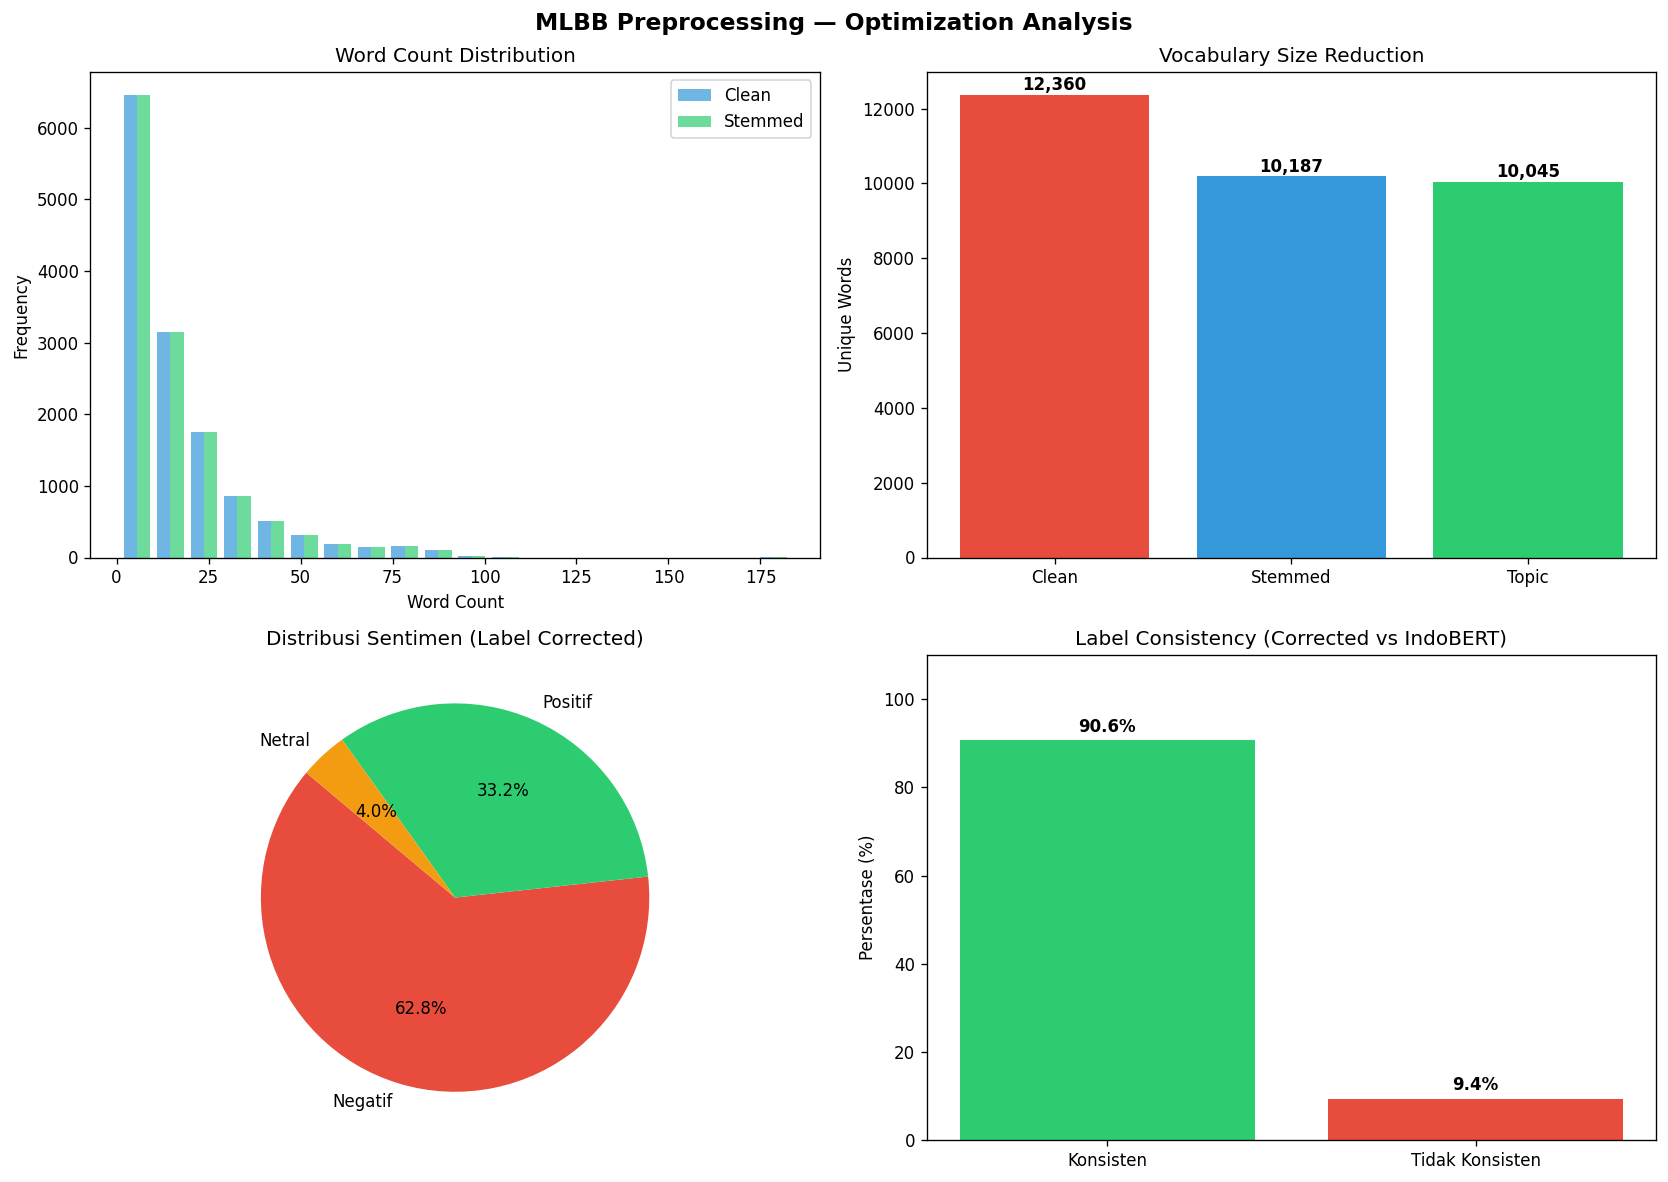

✅ Visualization tersimpan: optimization_analysis.png


In [31]:
# ================================================================
# OPTIMIZATION ANALYSIS — Vocabulary & Word Frequency Report
# (dari optimize.py)
# ================================================================

# Vocabulary comparison
vocab_clean   = set(' '.join(df['review_clean'].astype(str)).split())
vocab_stemmed = set(' '.join(df['review_stemmed'].astype(str)).split())
vocab_topic   = set(' '.join(df['review_topic'].astype(str)).split())

print('📚 Vocabulary Size:')
print(f'   review_clean   : {len(vocab_clean):,} kata unik')
print(f'   review_stemmed : {len(vocab_stemmed):,} kata unik  (-{len(vocab_clean)-len(vocab_stemmed):,} by stemming)')
print(f'   review_topic   : {len(vocab_topic):,} kata unik  (-{len(vocab_stemmed)-len(vocab_topic):,} by stopword)')

# Word count stats
df['words_clean']   = df['review_clean'].str.split().str.len()
df['words_stemmed'] = df['review_stemmed'].str.split().str.len()

avg_len_clean   = df['words_clean'].mean()
avg_len_stemmed = df['words_stemmed'].mean()
print(f'\n📏 Avg words:')
print(f'   review_clean   : {avg_len_clean:.1f}')
print(f'   review_stemmed : {avg_len_stemmed:.1f}')

# Top words comparison
def get_top_words(series, n=15):
    all_text = ' '.join(series.astype(str))
    return Counter(all_text.split()).most_common(n)

print('\n🔤 Top 15 Kata — review_clean:')
for i, (w, c) in enumerate(get_top_words(df['review_clean']), 1):
    print(f'   {i:2d}. {w:25s}: {c:,}')

# Kata pendek mencurigakan
short_words = []
for text in df['review_clean']:
    short_words.extend([w for w in str(text).split() if len(w) == 2])
short_counter = Counter(short_words)
frequent_shorts = {w: c for w, c in short_counter.items() if c > 3}
if frequent_shorts:
    print(f'\n⚠️  Kata 2-karakter yang sering muncul ({len(frequent_shorts)} kata):')
    for word, count in sorted(frequent_shorts.items(), key=lambda x: -x[1])[:10]:
        print(f'   \'{word}\' : {count:,} kali')
else:
    print('\n✅ Tidak ada kata pendek mencurigakan')

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MLBB Preprocessing — Optimization Analysis', fontsize=14, fontweight='bold')

# Word count distribution
axes[0,0].hist([df['words_clean'], df['words_stemmed']],
               label=['Clean', 'Stemmed'], bins=20, alpha=0.7, color=['#3498db', '#2ecc71'])
axes[0,0].set_title('Word Count Distribution')
axes[0,0].set_xlabel('Word Count'); axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Vocabulary reduction
vocab_sizes = [len(vocab_clean), len(vocab_stemmed), len(vocab_topic)]
axes[0,1].bar(['Clean', 'Stemmed', 'Topic'], vocab_sizes, color=['#e74c3c','#3498db','#2ecc71'])
axes[0,1].set_title('Vocabulary Size Reduction')
axes[0,1].set_ylabel('Unique Words')
for i, v in enumerate(vocab_sizes):
    axes[0,1].text(i, v + max(vocab_sizes)*0.01, f'{v:,}', ha='center', fontweight='bold')

# Sentiment distribution (corrected)
dist = df['label_corrected'].value_counts()
colors_pie = [{'Positif':'#2ecc71','Netral':'#f39c12','Negatif':'#e74c3c'}.get(l,'gray') for l in dist.index]
axes[1,0].pie(dist.values, labels=dist.index, autopct='%1.1f%%', colors=colors_pie, startangle=140)
axes[1,0].set_title('Distribusi Sentimen (Label Corrected)')

# Label consistency
if 'indobert_label' in df.columns:
    cons  = (df['label_corrected'] == df['indobert_label']).mean() * 100
    incons = 100 - cons
    axes[1,1].bar(['Konsisten','Tidak Konsisten'], [cons, incons], color=['#2ecc71','#e74c3c'])
    axes[1,1].set_title('Label Consistency (Corrected vs IndoBERT)')
    axes[1,1].set_ylabel('Persentase (%)'); axes[1,1].set_ylim(0, 110)
    for i, v in enumerate([cons, incons]):
        axes[1,1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('optimization_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualization tersimpan: optimization_analysis.png')


## 🧠 Cell 12 — LSTM Model Setup & Training

In [32]:
import tensorflow as tf

# ================================================================
# LSTM CONFIG & DATA PREPARATION
# ================================================================
MAX_WORDS   = 20000
MAX_LEN     = 150
EMBED_DIM   = 256
LSTM_UNITS  = 192
DROPOUT     = 0.45
BATCH_SIZE  = 32
EPOCHS      = 8
NUM_CLASSES = 3  # Jumlah kelas sentimen: Negatif, Netral, Positif

# Tokenize menggunakan review_final (label corrected, bersih)
# Gunakan 'label_corrected' sebagai label final
df_model = df[df['label_corrected'].isin(['Negatif', 'Netral', 'Positif'])].copy()
df_model['label_id'] = df_model['label_corrected'].map({'Negatif': 0, 'Netral': 1, 'Positif': 2})

tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(df_model['review_clean'].astype(str))

X = pad_sequences(
    tokenizer_lstm.texts_to_sequences(df_model['review_clean'].astype(str)),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
y = to_categorical(df_model['label_id'].values, num_classes=NUM_CLASSES)

# Train / Val / Test Split (70 / 15 / 15)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)  # 0.176 × 0.85 ≈ 0.15

print(f'✅ Data siap untuk LSTM')
print(f'   Vocab size           : {len(tokenizer_lstm.word_index):,}')
print(f'   X shape              : {X.shape}')
print(f'   Train / Val / Test   : {len(X_train):,} / {len(X_val):,} / {len(X_test):,}')
print(f'   Label map            : {LABEL_MAP}')

✅ Data siap untuk LSTM
   Vocab size           : 12,296
   X shape              : (13676, 150)
   Train / Val / Test   : 9,578 / 2,046 / 2,052
   Label map            : {'Negatif': 0, 'Netral': 1, 'Positif': 2}


In [33]:
# ================================================================
# CLASS WEIGHT (handle imbalance)
# ================================================================

y_train_labels = np.argmax(y_train, axis=1)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights_arr))
print('⚖️  Class weights:', {k: f'{v:.3f}' for k, v in class_weight_dict.items()})


⚖️  Class weights: {0: '0.531', 1: '8.314', 2: '1.005'}


In [34]:
def build_lstm_model(vocab_size, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, 256, input_length=max_len, mask_zero=True),
        SpatialDropout1D(0.3),

        # Layer 1
        Bidirectional(LSTM(192, return_sequences=True, dropout=0.4)),

        # Layer 2
        Bidirectional(LSTM(128, dropout=0.4)),

        # Dense layers
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(64, activation='relu'),
        Dropout(0.4),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),  # lebih kecil
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [35]:
# ================================================================
# TRAINING
# ================================================================

# Membangun model
model = build_lstm_model(vocab_size=MAX_WORDS, max_len=MAX_LEN, num_classes=NUM_CLASSES)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_lstm_mlbb.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('🚀 Memulai training Bidirectional LSTM...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print('✅ Training selesai!')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

🚀 Memulai training Bidirectional LSTM...
Epoch 1/30
299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4908 - loss: 1.0207
Epoch 1: val_accuracy improved from None to 0.63441, saving model to best_lstm_mlbb.keras

Epoch 1: finished saving model to best_lstm_mlbb.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.5574 - loss: 0.8969 - val_accuracy: 0.6344 - val_loss: 0.9294 - learning_rate: 3.0000e-04
Epoch 2/30
299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7059 - loss: 0.6065
Epoch 2: val_accuracy improved from 0.63441 to 0.74536, saving model to best_lstm_mlbb.keras

Epoch 2: finished saving model to best_lstm_mlbb.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.7177 - loss: 0.6037 - val_accuracy: 0.7454 - val_loss: 0.5918 - learning_rate: 3.0000e-04
Epoch 3/30
298/300 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7792 - loss: 0.4786
Epoch 3: val_accuracy improved from 0.74536 to 0.77908, saving model to best_lstm_mlbb.keras

Epoch 3: finishe

In [36]:
# ================================================================
# TRAINING
# ================================================================

# Membangun model
model = build_lstm_model(vocab_size=MAX_WORDS, max_len=MAX_LEN, num_classes=NUM_CLASSES)
model.summary()

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_lstm_mlbb.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('🚀 Memulai training Bidirectional LSTM...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)
print('✅ Training selesai!')

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

🚀 Memulai training Bidirectional LSTM...
Epoch 1/8
299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4520 - loss: 0.9967
Epoch 1: val_accuracy improved from None to 0.78837, saving model to best_lstm_mlbb.keras

Epoch 1: finished saving model to best_lstm_mlbb.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.5479 - loss: 0.8941 - val_accuracy: 0.7884 - val_loss: 0.8642 - learning_rate: 3.0000e-04
Epoch 2/8
298/300 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6979 - loss: 0.6406
Epoch 2: val_accuracy did not improve from 0.78837
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7231 - loss: 0.6081 - val_accuracy: 0.7815 - val_loss: 0.5680 - learning_rate: 3.0000e-04
Epoch 3/8
299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7879 - loss: 0.4388
Epoch 3: val_accuracy improved from 0.78837 to 0.79423, saving model to best_lstm_mlbb.keras

Epoch 3: finished saving model to best_lstm_mlbb.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.7976 -

## 📊 Cell 13 — Evaluation & Visualisasi

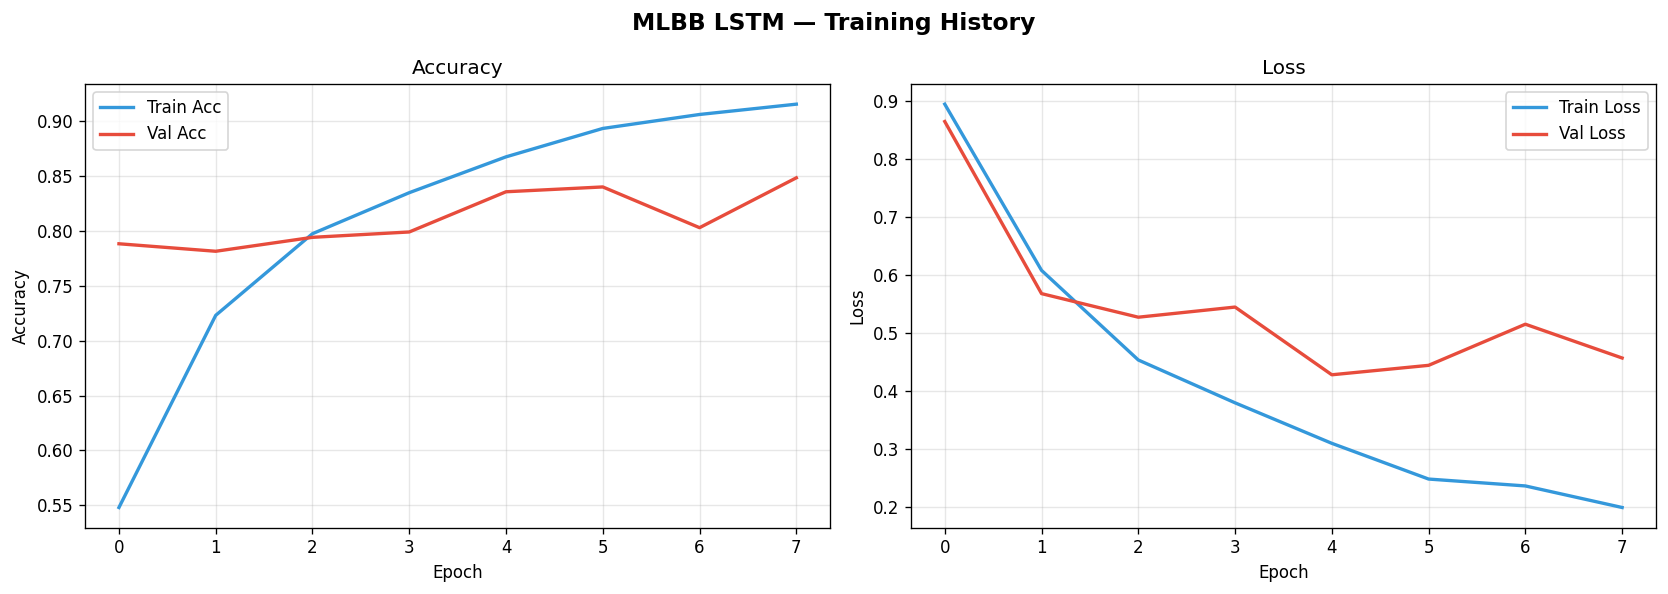

In [37]:
# ================================================================
# TRAINING CURVES
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLBB LSTM — Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Acc', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc',   color='#e74c3c', linewidth=2)
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()



🎯 TEST SET RESULTS
   Accuracy : 84.75%
   Loss     : 0.4686

📋 Classification Report:
              precision    recall  f1-score   support

     Negatif       0.91      0.88      0.90      1290
      Netral       0.32      0.67      0.43        82
     Positif       0.87      0.80      0.83       680

    accuracy                           0.85      2052
   macro avg       0.70      0.79      0.72      2052
weighted avg       0.87      0.85      0.86      2052



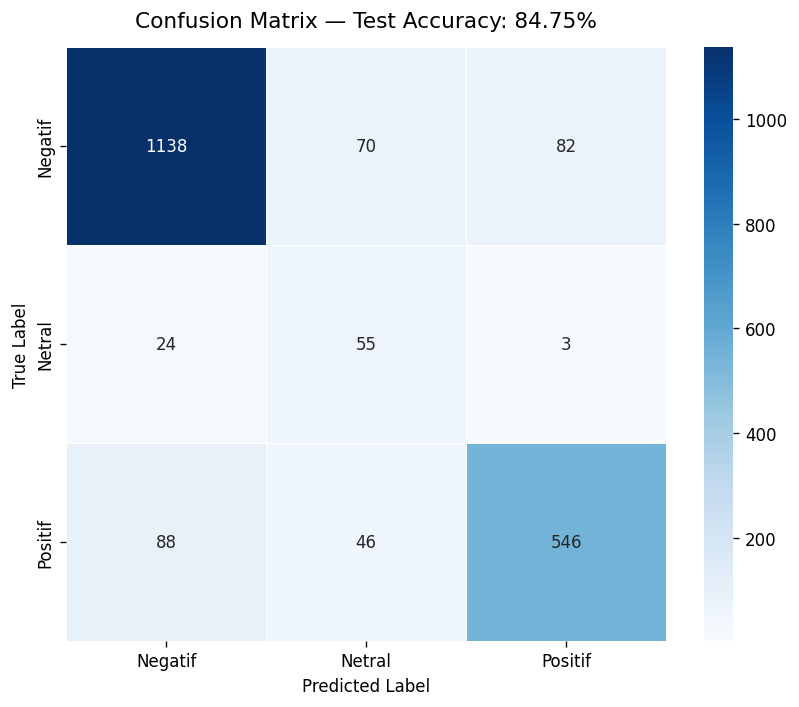

In [38]:
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

LABEL_NAMES = ['Negatif', 'Netral', 'Positif']

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\n🎯 TEST SET RESULTS')
print(f'   Accuracy : {test_acc*100:.2f}%')
print(f'   Loss     : {test_loss:.4f}')

print(f'\n📋 Classification Report:')
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES, labels=list(LABEL_MAP.values())))

# Confusion Matrix
from sklearn.metrics import f1_score
cm = confusion_matrix(y_true, y_pred, labels=list(LABEL_MAP.values())) # Add labels here too for consistency
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            ax=ax, linewidths=0.5)
ax.set_title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%', fontsize=13, pad=12)
ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 💾 Cell 14 — Export Dataset & Model

In [39]:
# ================================================================
# EXPORT FINAL DATASET
# ================================================================

import pickle

# Kolom yang diexport
export_cols_priority = [
    'review',               # teks asli
    'rating',               # rating asli
    'review_clean',         # ✅ bersih untuk IndoBERT/LSTM
    'review_stemmed',       # ✅ untuk Traditional ML
    'review_topic',         # ✅ untuk Topic Modeling
    'sentiment_label',      # label asal (dari rating)
    'vader_label',          # prediksi VADER
    'indobert_label',       # prediksi IndoBERT
    'indobert_score',       # confidence IndoBERT
    'label_corrected',      # ✅ label final setelah koreksi
    'label_id',             # encoded (0/1/2)
]
# Tambahkan kolom lain yang ada (tanggal, dll)
extra_cols = [c for c in df.columns if c not in export_cols_priority]
available_cols = [c for c in export_cols_priority + extra_cols if c in df.columns]

df_export = df[available_cols].copy()

output_path = 'mlbb_reviews_FINAL.csv'
df_export.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'✅ Dataset final tersimpan: {output_path}')
print(f'   Rows   : {len(df_export):,}')
print(f'   Kolom  : {list(df_export.columns)}')
print(f'\n📊 Distribusi Label Final:')
print(df_export['label_corrected'].value_counts())

# Simpan tokenizer
with open('tokenizer_lstm_mlbb.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)

print('\n✅ Model tersimpan  : best_lstm_mlbb.keras')
print('✅ Tokenizer tersimpan: tokenizer_lstm_mlbb.pkl')


✅ Dataset final tersimpan: mlbb_reviews_FINAL.csv
   Rows   : 13,676
   Kolom  : ['review', 'rating', 'review_clean', 'review_stemmed', 'review_topic', 'sentiment_label', 'vader_label', 'indobert_label', 'indobert_score', 'label_corrected', 'label_id', 'tanggal', 'review_length', 'word_count', 'bulan', 'review_raw', 'review_clean_length', 'review_clean_words', 'sentiment_id', 'vader_pos', 'vader_neg', 'vader_neu', 'vader_compound', 'words_clean', 'words_stemmed']

📊 Distribusi Label Final:
label_corrected
Negatif    8594
Positif    4534
Netral      548
Name: count, dtype: int64

✅ Model tersimpan  : best_lstm_mlbb.keras
✅ Tokenizer tersimpan: tokenizer_lstm_mlbb.pkl


## 🔬 Cell 12b — Skema Pelatihan Alternatif (SVM & Random Forest)

Dua skema tambahan untuk memenuhi persyaratan **3 percobaan skema pelatihan berbeda**:

| Skema | Algoritma | Ekstraksi Fitur | Split |
|-------|-----------|-----------------|-------|
| 1 | BiLSTM (Deep Learning) | Embedding | 70/15/15 |
| 2 | SVM | TF-IDF | 80/20 |
| 3 | Random Forest | TF-IDF | 70/30 |


🔬 SKEMA 2: SVM + TF-IDF — Split 80/20
   Train: 10,940  |  Test: 2,736

✅ SVM Test Accuracy : 86.26%

📋 Classification Report — SVM:
              precision    recall  f1-score   support

     Negatif       0.88      0.93      0.90      1719
      Netral       0.45      0.37      0.41       110
     Positif       0.87      0.79      0.83       907

    accuracy                           0.86      2736
   macro avg       0.73      0.70      0.71      2736
weighted avg       0.86      0.86      0.86      2736



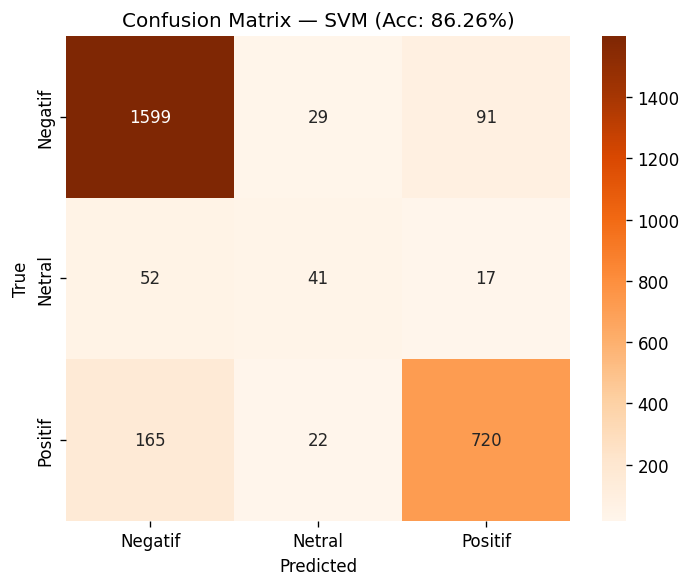

✅ Model SVM tersimpan: svm_tfidf_mlbb.pkl

🔬 SKEMA 3: Random Forest + TF-IDF — Split 70/30
   Train: 9,573  |  Test: 4,103

✅ RF Test Accuracy : 84.16%

📋 Classification Report — Random Forest:
              precision    recall  f1-score   support

     Negatif       0.84      0.95      0.89      2578
      Netral       0.48      0.20      0.28       165
     Positif       0.87      0.71      0.78      1360

    accuracy                           0.84      4103
   macro avg       0.73      0.62      0.65      4103
weighted avg       0.84      0.84      0.83      4103



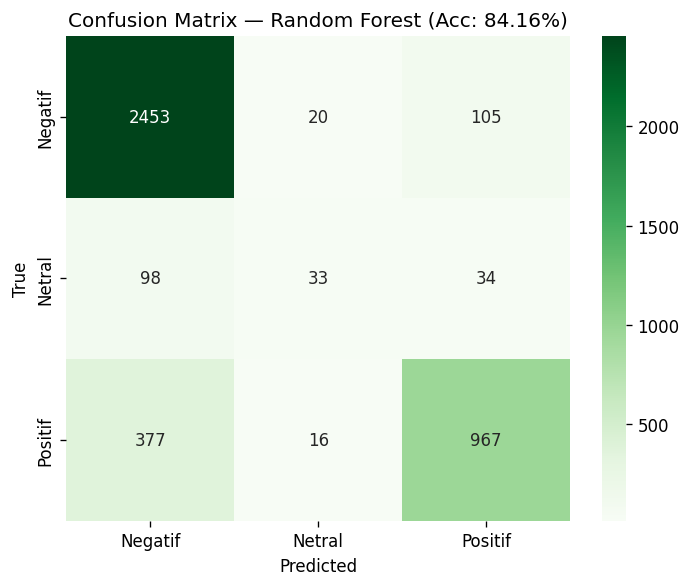

✅ Model RF tersimpan: rf_tfidf_mlbb.pkl

📊 PERBANDINGAN 3 SKEMA PELATIHAN
  Skema                            Accuracy   F1-Macro
  ----------------------------------------------------
  1. BiLSTM + Embedding (70/15/15)     84.75%     72.13%
  2. SVM + TF-IDF (80/20)            86.26%     71.35%
  3. RF + TF-IDF (70/30)             84.16%     65.24%


In [42]:
# ================================================================
# SKEMA 2 — SVM + TF-IDF (80/20 split)
# ================================================================
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pickle

print('=' * 60)
print('🔬 SKEMA 2: SVM + TF-IDF — Split 80/20')
print('=' * 60)

df_ml = df[df['label_corrected'].isin(['Negatif', 'Netral', 'Positif'])].copy()
X_text = df_ml['review_stemmed'].astype(str)
y_label = df_ml['label_corrected']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_text, y_label, test_size=0.20, random_state=42, stratify=y_label
)
print(f'   Train: {len(X_train2):,}  |  Test: {len(X_test2):,}')

pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LinearSVC(
        C=1.0,
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

pipeline_svm.fit(X_train2, y_train2)
y_pred2 = pipeline_svm.predict(X_test2)

acc_svm = accuracy_score(y_test2, y_pred2)
print(f'\n✅ SVM Test Accuracy : {acc_svm*100:.2f}%')
print(f'\n📋 Classification Report — SVM:')
print(classification_report(y_test2, y_pred2, target_names=['Negatif', 'Netral', 'Positif']))

# Confusion matrix SVM
cm_svm = confusion_matrix(y_test2, y_pred2, labels=['Negatif', 'Netral', 'Positif'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negatif','Netral','Positif'],
            yticklabels=['Negatif','Netral','Positif'], ax=ax)
ax.set_title(f'Confusion Matrix — SVM (Acc: {acc_svm*100:.2f}%)', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=120, bbox_inches='tight')
plt.show()

# Simpan model SVM
with open('svm_tfidf_mlbb.pkl', 'wb') as f:
    pickle.dump(pipeline_svm, f)
print('✅ Model SVM tersimpan: svm_tfidf_mlbb.pkl')


# ================================================================
# SKEMA 3 — Random Forest + TF-IDF (70/30 split)
# ================================================================
from sklearn.ensemble import RandomForestClassifier

print('\n' + '=' * 60)
print('🔬 SKEMA 3: Random Forest + TF-IDF — Split 70/30')
print('=' * 60)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_text, y_label, test_size=0.30, random_state=42, stratify=y_label
)
print(f'   Train: {len(X_train3):,}  |  Test: {len(X_test3):,}')

pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    ))
])

pipeline_rf.fit(X_train3, y_train3)
y_pred3 = pipeline_rf.predict(X_test3)

acc_rf = accuracy_score(y_test3, y_pred3)
print(f'\n✅ RF Test Accuracy : {acc_rf*100:.2f}%')
print(f'\n📋 Classification Report — Random Forest:')
print(classification_report(y_test3, y_pred3, target_names=['Negatif', 'Netral', 'Positif']))

# Confusion matrix RF
cm_rf = confusion_matrix(y_test3, y_pred3, labels=['Negatif', 'Netral', 'Positif'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negatif','Netral','Positif'],
            yticklabels=['Negatif','Netral','Positif'], ax=ax)
ax.set_title(f'Confusion Matrix — Random Forest (Acc: {acc_rf*100:.2f}%)', fontsize=12)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('cm_rf.png', dpi=120, bbox_inches='tight')
plt.show()

# Simpan model RF
with open('rf_tfidf_mlbb.pkl', 'wb') as f:
    pickle.dump(pipeline_rf, f)
print('✅ Model RF tersimpan: rf_tfidf_mlbb.pkl')

# ================================================================
# RINGKASAN PERBANDINGAN 3 SKEMA
# ================================================================
from sklearn.metrics import f1_score as f1

# BiLSTM sudah dihitung sebelumnya (test_acc, y_true, y_pred)
f1_macro = f1(y_true, y_pred, average='macro') # Calculate f1_macro for BiLSTM here
f1_svm = f1(y_test2, y_pred2, average='macro')
f1_rf  = f1(y_test3, y_pred3, average='macro')

print('\n' + '=' * 65)
print('📊 PERBANDINGAN 3 SKEMA PELATIHAN')
print('=' * 65)
print(f'  {'Skema':<30} {'Accuracy':>10} {'F1-Macro':>10}')
print(f'  {'-'*52}')
print(f'  {'1. BiLSTM + Embedding (70/15/15)':<30} {test_acc*100:>9.2f}% {f1_macro*100:>9.2f}%')
print(f'  {'2. SVM + TF-IDF (80/20)':<30} {acc_svm*100:>9.2f}% {f1_svm*100:>9.2f}%')
print(f'  {'3. RF + TF-IDF (70/30)':<30} {acc_rf*100:>9.2f}% {f1_rf*100:>9.2f}%')
print('=' * 65)

## 🔮 Cell 15 — Inference Function

In [43]:
# ================================================================
# INFERENCE — Prediksi Sentimen Review Baru
# ================================================================

def predict_sentiment(text, model, tokenizer, max_len=150):
    """Prediksi sentimen satu review baru."""
    cleaned = preprocess_full(text, apply_stopword=False, apply_stem=False)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob    = model.predict(padded, verbose=0)[0]
    label_idx = np.argmax(prob)
    labels = ['Negatif', 'Netral', 'Positif']
    return {
        'text_original' : text,
        'text_cleaned'  : cleaned,
        'sentiment'     : labels[label_idx],
        'confidence'    : f'{prob[label_idx]*100:.1f}%',
        'scores'        : {l: f'{p*100:.1f}%' for l, p in zip(labels, prob)},
    }

# Test inference
test_reviews = [
    'game ini sampah banget, lag mulu, moonton gak pernah benerin!',
    'lumayan sih gamenya, tapi kadang sering dc',
    'graphics keren banget, gameplay seru dan smooth, love this game!',
    'feeder mulu timku, matchmaking ancur, uninstall ah',
    'update terbaru bagus banget, banyak hero baru yang menarik',
]

SENTIMENT_ICON = {'Negatif': '😡', 'Netral': '😐', 'Positif': '😊'}

print('🔮 Contoh Prediksi Sentimen:')
print('='*60)
for review in test_reviews:
    result = predict_sentiment(review, model, tokenizer_lstm)
    icon = SENTIMENT_ICON.get(result['sentiment'], '❓')
    r_txt = f"'{review[:55]}...'" if len(review) > 55 else f"'{review}'"
    print(f"\n📝 {r_txt}")
    print(f"   Sentimen : {icon} {result['sentiment']} ({result['confidence']})")
    print(f"   Scores   : {result['scores']}")


🔮 Contoh Prediksi Sentimen:

📝 'game ini sampah banget, lag mulu, moonton gak pernah be...'
   Sentimen : 😡 Negatif (100.0%)
   Scores   : {'Negatif': '100.0%', 'Netral': '0.0%', 'Positif': '0.0%'}

📝 'lumayan sih gamenya, tapi kadang sering dc'
   Sentimen : 😊 Positif (81.7%)
   Scores   : {'Negatif': '17.6%', 'Netral': '0.8%', 'Positif': '81.7%'}

📝 'graphics keren banget, gameplay seru dan smooth, love t...'
   Sentimen : 😊 Positif (100.0%)
   Scores   : {'Negatif': '0.0%', 'Netral': '0.0%', 'Positif': '100.0%'}

📝 'feeder mulu timku, matchmaking ancur, uninstall ah'
   Sentimen : 😡 Negatif (100.0%)
   Scores   : {'Negatif': '100.0%', 'Netral': '0.0%', 'Positif': '0.0%'}

📝 'update terbaru bagus banget, banyak hero baru yang mena...'
   Sentimen : 😊 Positif (100.0%)
   Scores   : {'Negatif': '0.0%', 'Netral': '0.0%', 'Positif': '100.0%'}


## 📈 Cell 16 — Final Summary Report

In [44]:
# ================================================================
# FINAL SUMMARY
# ================================================================

f1_macro    = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print('='*65)
print('🏆 FINAL PIPELINE SUMMARY — MLBB SENTIMENT ANALYSIS')
print('='*65)
print(f"""
📂 DATASET
   Input CSV    : mlbb_reviews.csv
   Total rows   : {len(df):,}
   Label corrected: {changed:,} ({changed/len(df)*100:.1f}% dikoreksi)

📚 PREPROCESSING
   ✅ Kamus Slang     : {len(SLANG_DICT_FINAL)} entri (MLBB-specific)
   ✅ Emoji Map       : {len(EMOJI_TO_TEXT)} entri
   ✅ Stemming        : Gentle (skip {len(SENTIMENT_PROTECT)} kata sentimen penting)
   ✅ Stopwords       : {len(ALL_STOPWORDS)} kata difilter
   ✅ Output kolom    :
      - review_clean         (untuk LSTM/IndoBERT)
      - review_stemmed       (untuk ML klasik)
      - review_topic         (untuk topic modeling)

🎯 LABEL CORRECTION
   ✅ Konsistensi sebelum: {consistency_before:.1f}%
   ✅ Konsistensi setelah: {consistency_after:.1f}%
   ✅ Metode: Keyword counting + Regex + IndoBERT fallback

🧠 LSTM MODEL
   Architecture : Bidirectional LSTM × 2 + Dense
   Vocab size   : {min(MAX_WORDS, len(tokenizer_lstm.word_index)):,}
   Max sequence : {MAX_LEN} tokens
   Embedding    : {EMBED_DIM}d
   LSTM units   : {LSTM_UNITS} (Bidirectional)

📊 PERFORMANCE (Test Set)
   Accuracy   : {test_acc*100:.2f}%
   F1 Macro   : {f1_macro*100:.2f}%
   F1 Weighted: {f1_weighted*100:.2f}%

💾 OUTPUT FILES
   mlbb_reviews_FINAL.csv      ← Dataset final
   best_lstm_mlbb.keras         ← Model terbaik
   tokenizer_lstm_mlbb.pkl      ← Tokenizer LSTM
   svm_tfidf_mlbb.pkl           ← Model SVM (Pipeline TF-IDF + SVM)
   rf_tfidf_mlbb.pkl            ← Model RF  (Pipeline TF-IDF + RF)
   eda_overview.png             ← EDA overview
   sentiment_distribution.png  ← Distribusi sentimen
   label_distribution.png      ← Before/after koreksi label
   optimization_analysis.png   ← Vocabulary analysis
   training_curves.png          ← Kurva training
   confusion_matrix.png         ← Confusion matrix
""")
print('='*65)


🏆 FINAL PIPELINE SUMMARY — MLBB SENTIMENT ANALYSIS

📂 DATASET
   Input CSV    : mlbb_reviews.csv
   Total rows   : 13,676
   Label corrected: 3,482 (25.5% dikoreksi)

📚 PREPROCESSING
   ✅ Kamus Slang     : 509 entri (MLBB-specific)
   ✅ Emoji Map       : 37 entri
   ✅ Stemming        : Gentle (skip 82 kata sentimen penting)
   ✅ Stopwords       : 813 kata difilter
   ✅ Output kolom    :
      - review_clean         (untuk LSTM/IndoBERT)
      - review_stemmed       (untuk ML klasik)
      - review_topic         (untuk topic modeling)

🎯 LABEL CORRECTION
   ✅ Konsistensi sebelum: 76.0%
   ✅ Konsistensi setelah: 90.6%
   ✅ Metode: Keyword counting + Regex + IndoBERT fallback

🧠 LSTM MODEL
   Architecture : Bidirectional LSTM × 2 + Dense
   Vocab size   : 12,296
   Max sequence : 150 tokens
   Embedding    : 256d
   LSTM units   : 192 (Bidirectional)

📊 PERFORMANCE (Test Set)
   Accuracy   : 84.75%
   F1 Macro   : 72.13%
   F1 Weighted: 85.67%

💾 OUTPUT FILES
   mlbb_reviews_FINAL.csv    